# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA 모델 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A2.시계열 분석에서 정상성이 중요한 이유는 모델이 미래 값을 예측할 때, 데이터의 평균과 분산이 시간에 따라 일정하다는 가정 하에서 안정적으로 패턴을 학습할 수 있기 때문이다.
ARIMA 모델은 비정상성을 처리하기 위해 차분을 사용하는데, 차분 연산을 통해 시계열의 추세나 계절성 등을 제거하여 평균과 분산이 일정한 정상 시계열로 변환한 후, AR(자기회귀)와 MA(이동평균) 성분을 적용하여 예측을 수행한다.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2. 주어진 시계열은 원 시계열의 ACF가 천천히 감소하고 PACF가 1시차에서 큰 값을 보이는 등 장기 의존성을 보여 비정상적이다. 하지만 1차 차분 후 ACF가 절단 형태를 보이고 PACF가 점진적으로 감소하며 분산이 안정적이므로 정상성을 만족한다. 따라서 1차 차분을 적용한 ARIMA(1,1,1) 모형이 적절하다.

## 실습: ARIMA  
- **ARIMA** 모델 실습입니다. 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)로, 아래 코드를 통해 간단하게 불러올 수 있습니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smid80/weatherww2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weatherww2' dataset.
Path to dataset files: /kaggle/input/weatherww2


In [7]:
print(os.listdir(path))

['Summary of Weather.csv', 'Weather Station Locations.csv']


In [ ]:
# kaggle 기본 제공 코드
import os

path = "/root/.cache/kagglehub/datasets/smid80/weatherww2/versions/1"

print(os.listdir(path))

In [11]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_file_path = os.path.join(path, "Weather Station Locations.csv")
loc_df = pd.read_csv(loc_file_path)
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [12]:
# station별 실제 날씨 데이터
weather_file_path = os.path.join(path, "Summary of Weather.csv")
weather_df = pd.read_csv(weather_file_path)

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 수치형 값으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

/tmp/ipykernel_168/329226695.py:3: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(weather_file_path)


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [13]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

/tmp/ipykernel_168/3926248603.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  weather_bin = weather_df[weather_df.STA == int(loc_sta)]
/tmp/ipykernel_168/3926248603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


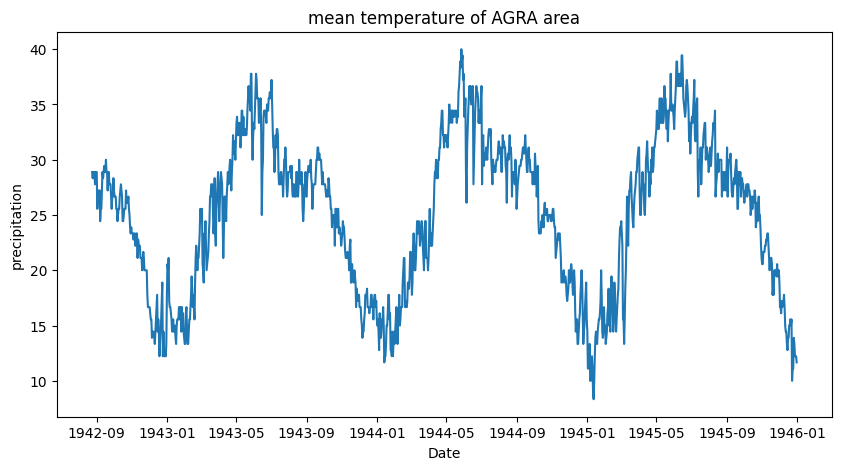

In [14]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [15]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

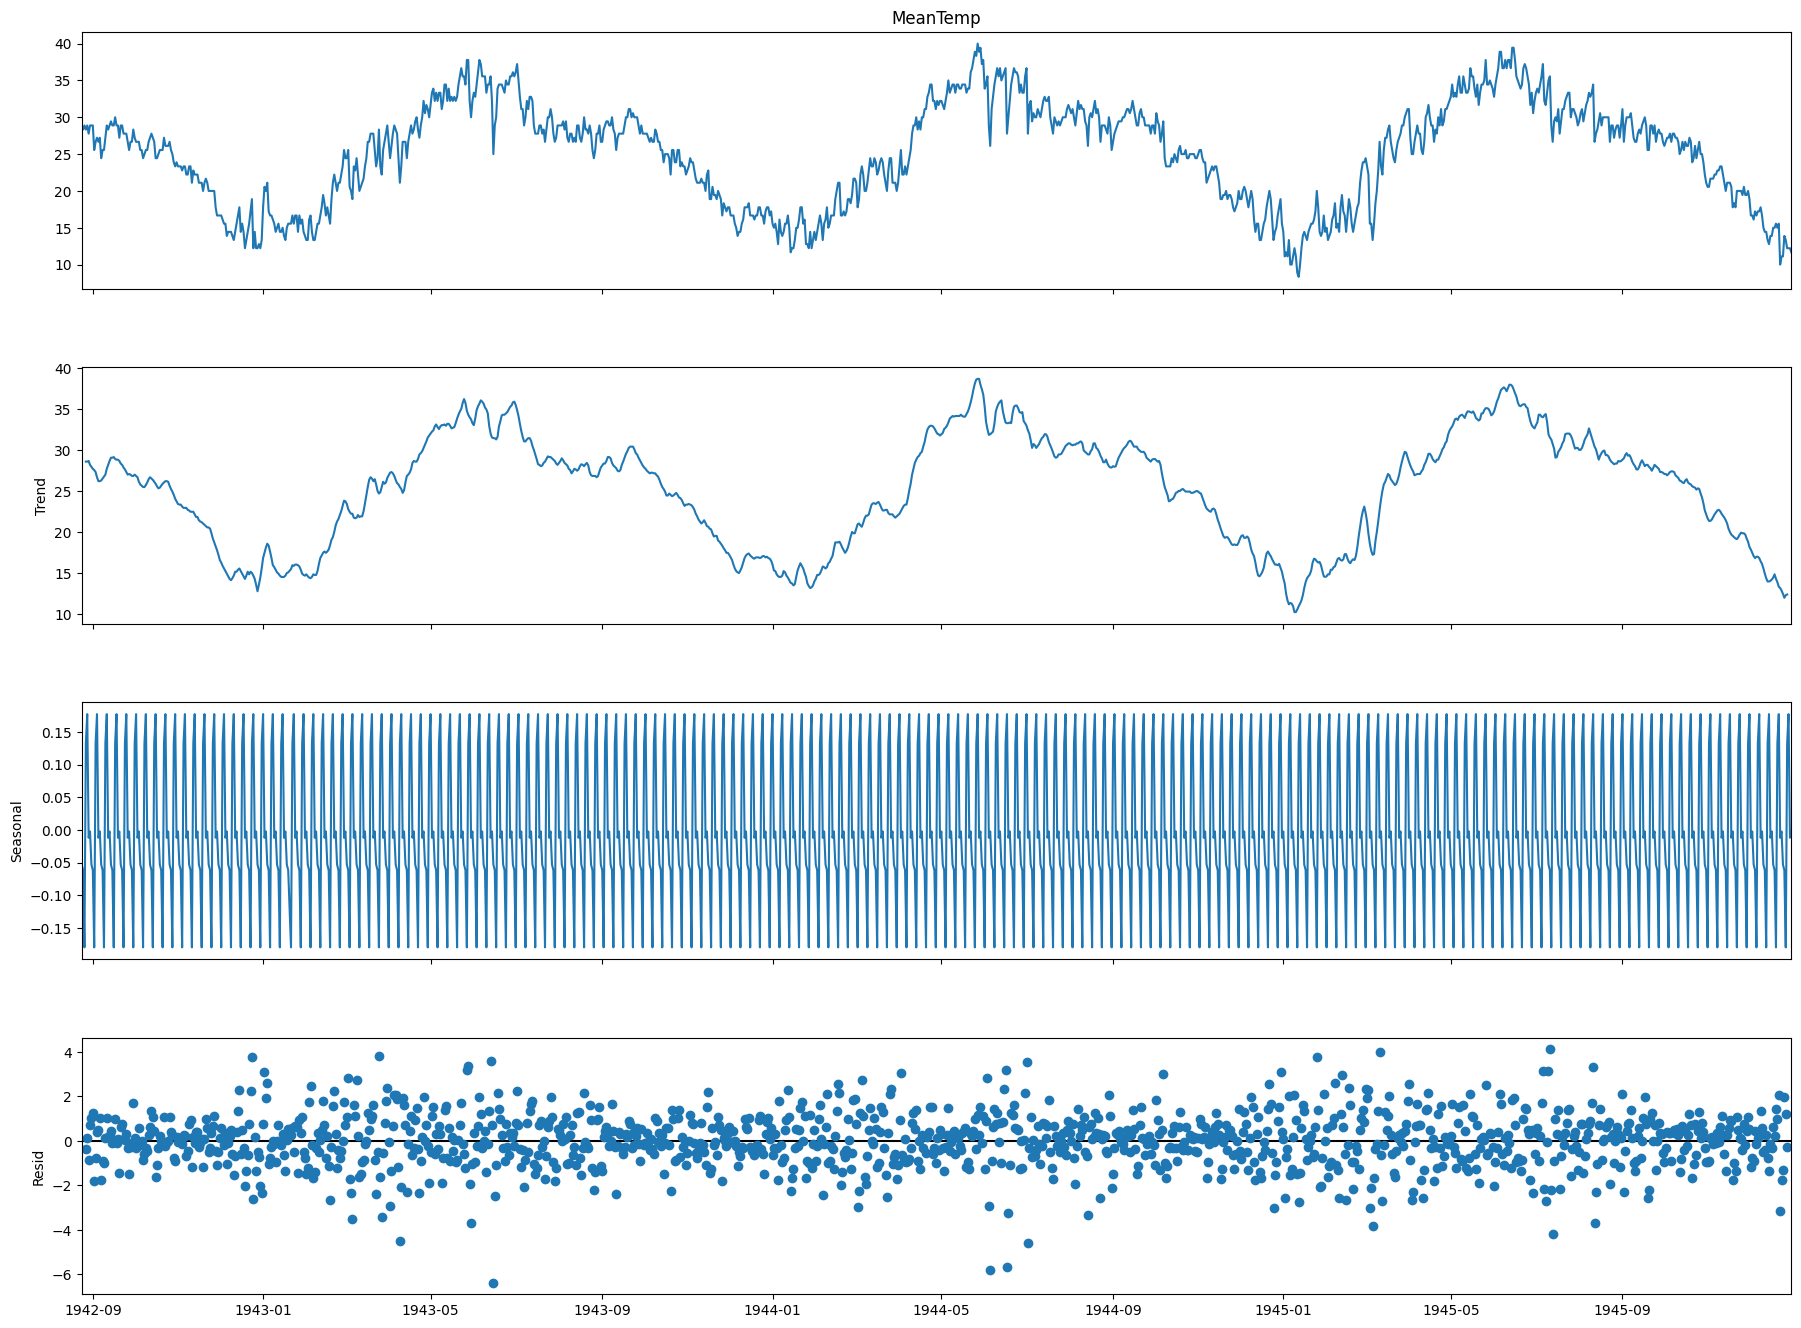

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

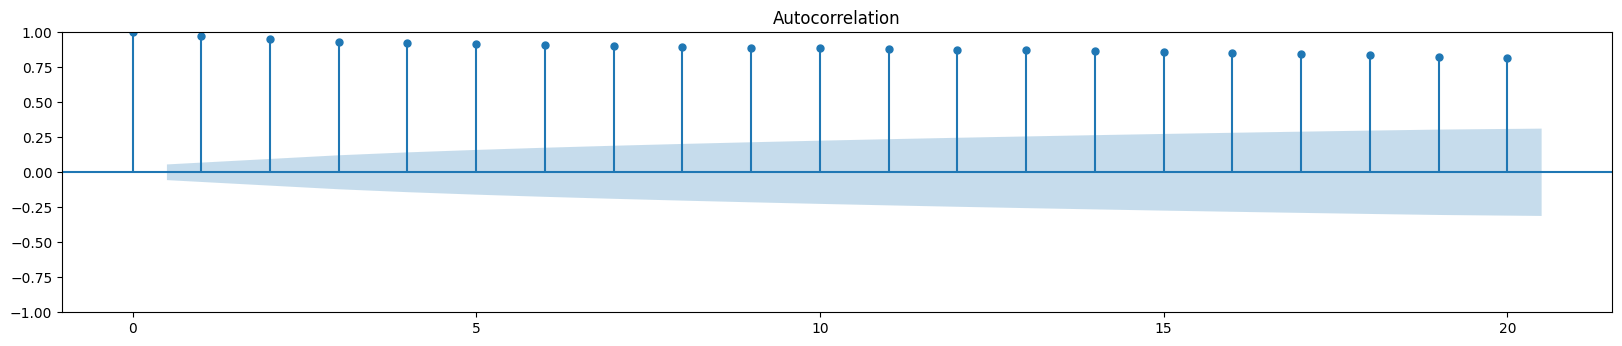

In [17]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [18]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설과 귀무가설이라는 키워드를 사용하여 서술하세요.

A1.ADF 검정 결과를 통해 p-value가 0.05보다 크고 ADF 통계량이 임계값보다 높기 때문에 귀무가설(시계열이 비정상적이다)을 기각할 수 없으며, 따라서 해당 시계열은 비정상성을 가진다고 판단할 수 있다.

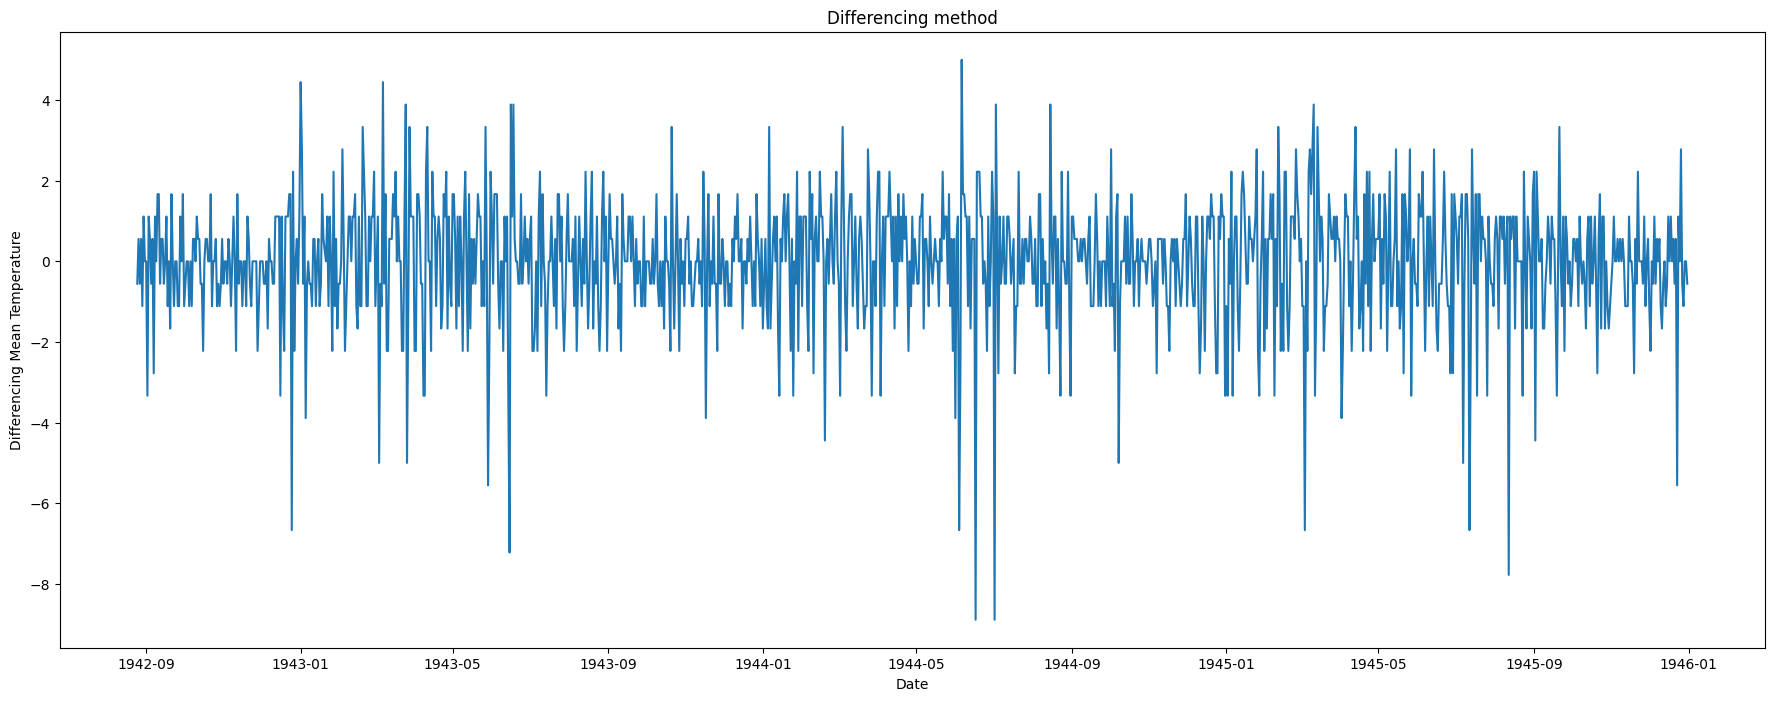

In [19]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [20]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2.1차 차분을 적용하자 ADF 통계량이 임계값보다 낮아지고 p-value가 0으로 감소하여 귀무가설(비정상성)을 기각할 수 있게 되었으며, 이는 차분을 통해 시계열의 추세를 제거하여 정상성을 확보했기 때문이다.

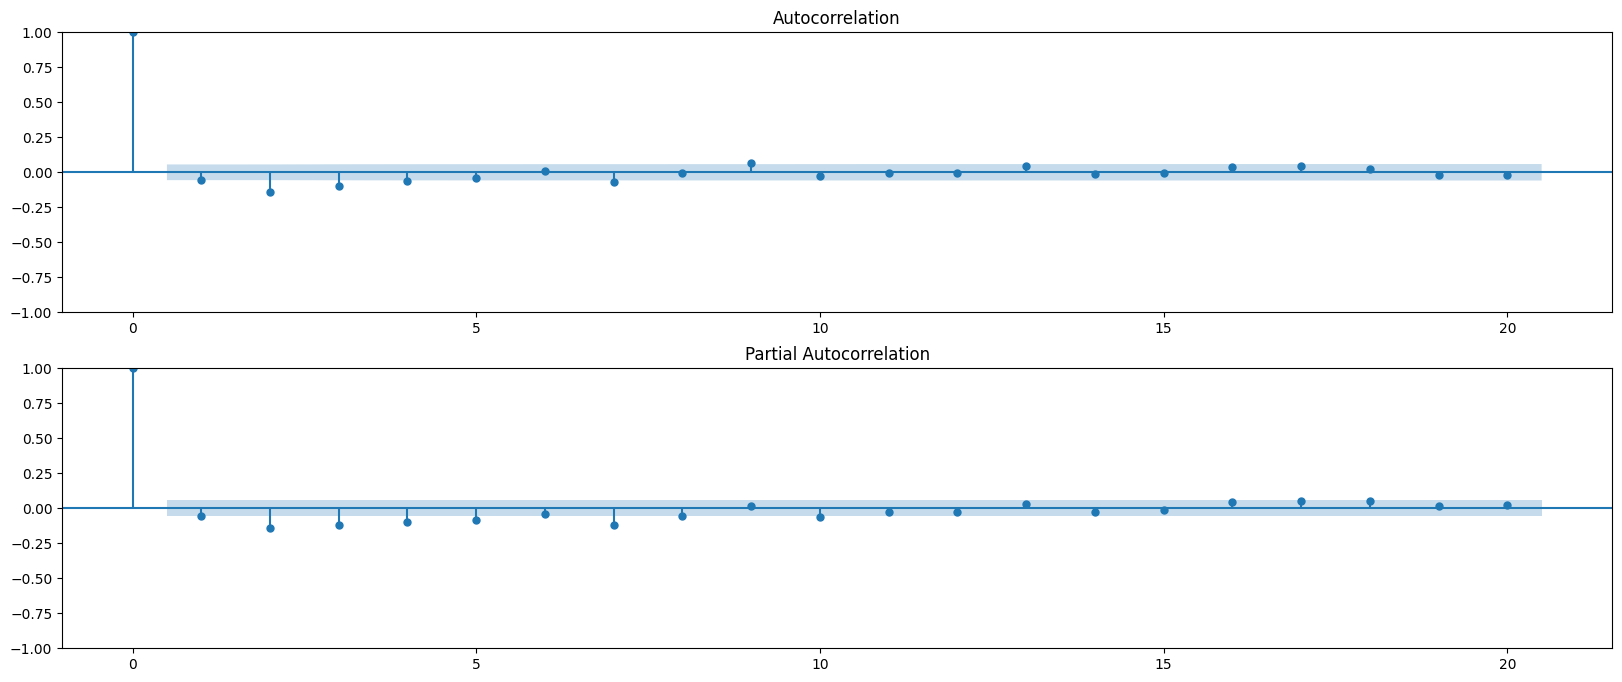

In [21]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3. 위 그래프는 시계열의 자기상관함수(ACF)와 부분자기상관함수(PACF)를 나타낸다. ACF가 천천히 감소하는 반면, PACF는 1시차에서 크게 나타난 후 점진적으로 감소하는 모습을 보인다. 이는 시계열이 AR(1) 성분을 포함하고 있음을 시사하며, 따라서 AR 차수인 p를 1로 설정하는 것이 적절하다. 반면, ACF가 점진적으로 감소하기 때문에 MA 차수인 q는 0으로 설정하는 것이 좋다. 또한, 차분을 통해 정상성을 확보했으므로 차분 차수 d는 1로 둔다. 따라서 ARIMA 모델의 하이퍼파라미터는 p=1, d=1, q=0으로 설정하는 것이 합리적이다.

### ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


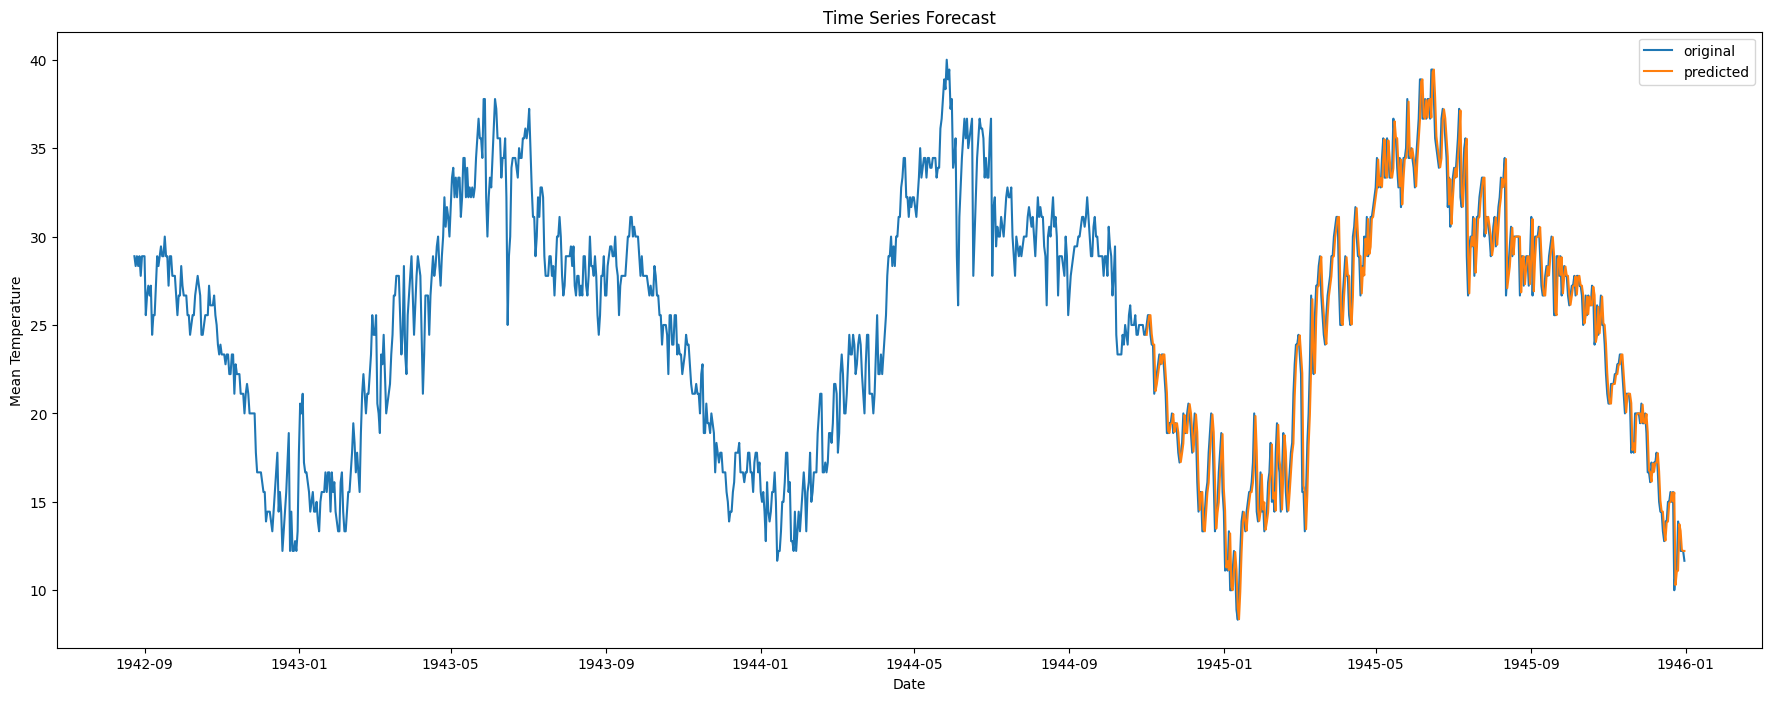

In [22]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 1
d = 1
q = 0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

/tmp/ipykernel_168/1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


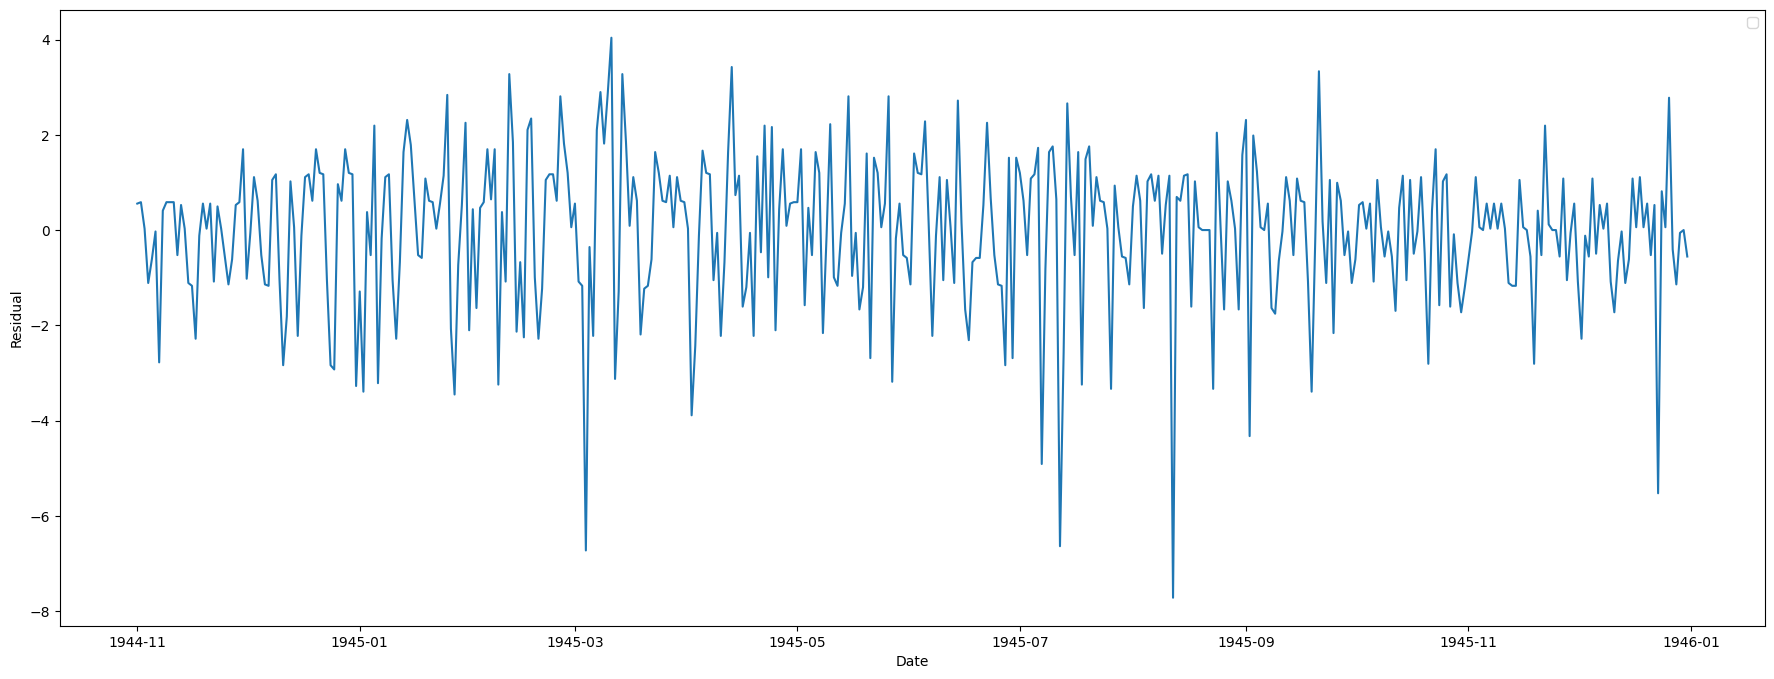

In [23]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

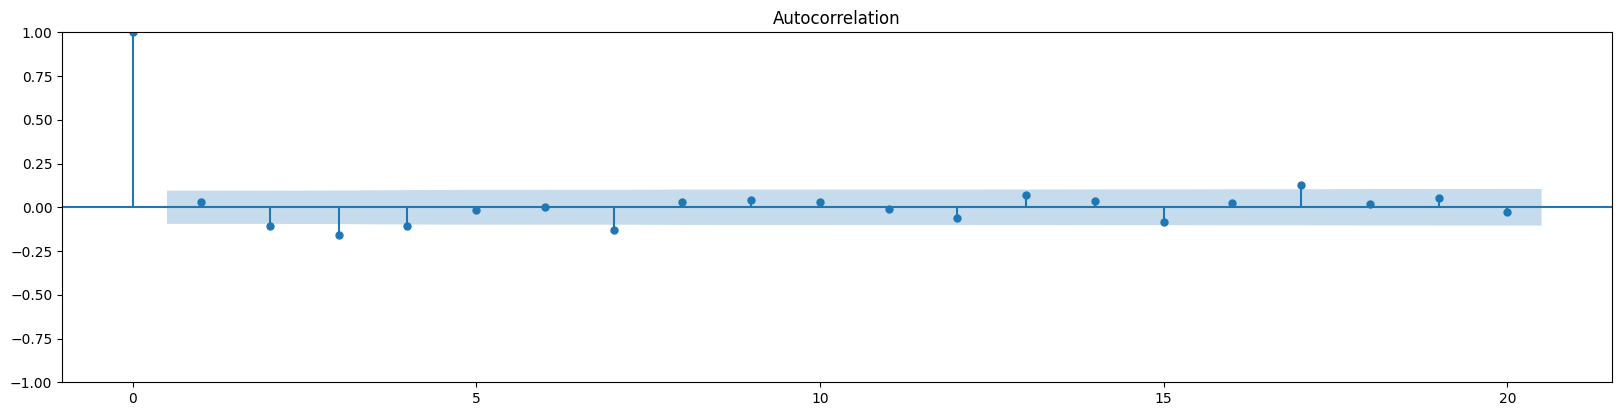

In [24]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [25]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.339884
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [26]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  # mae = round(metrics.mean_absolute_error(y_true, y_pred), 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [27]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.555,0.978,1.566,5.426


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4. 모델의 예측 결과는 실제값과 매우 높은 상관관계를 보이며, 낮은 RMSE와 MAPE로 정확도가 높음을 나타낸다. 전반적으로 모델이 시계열 데이터를 잘 예측하고 있다고 판단할 수 있다.

## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [29]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

,0
NAME,
ACCRA,1157
AGRA,1225
AMBERLY,848
AMURI/FIELD AAF,884
ATAR,876
...,...
TINDOUF,818
VAL DE CANS,1188
WALLER/BWI,1631


In [31]:
# 컬럼 이름 확인
print(merged.columns)

Index(['STA', 'Date', 'MaxTemp', 'MinTemp', 'MeanTemp', 'Precip', 'WBAN',
       'NAME'],
      dtype='object')



===== 분석: ACCRA =====


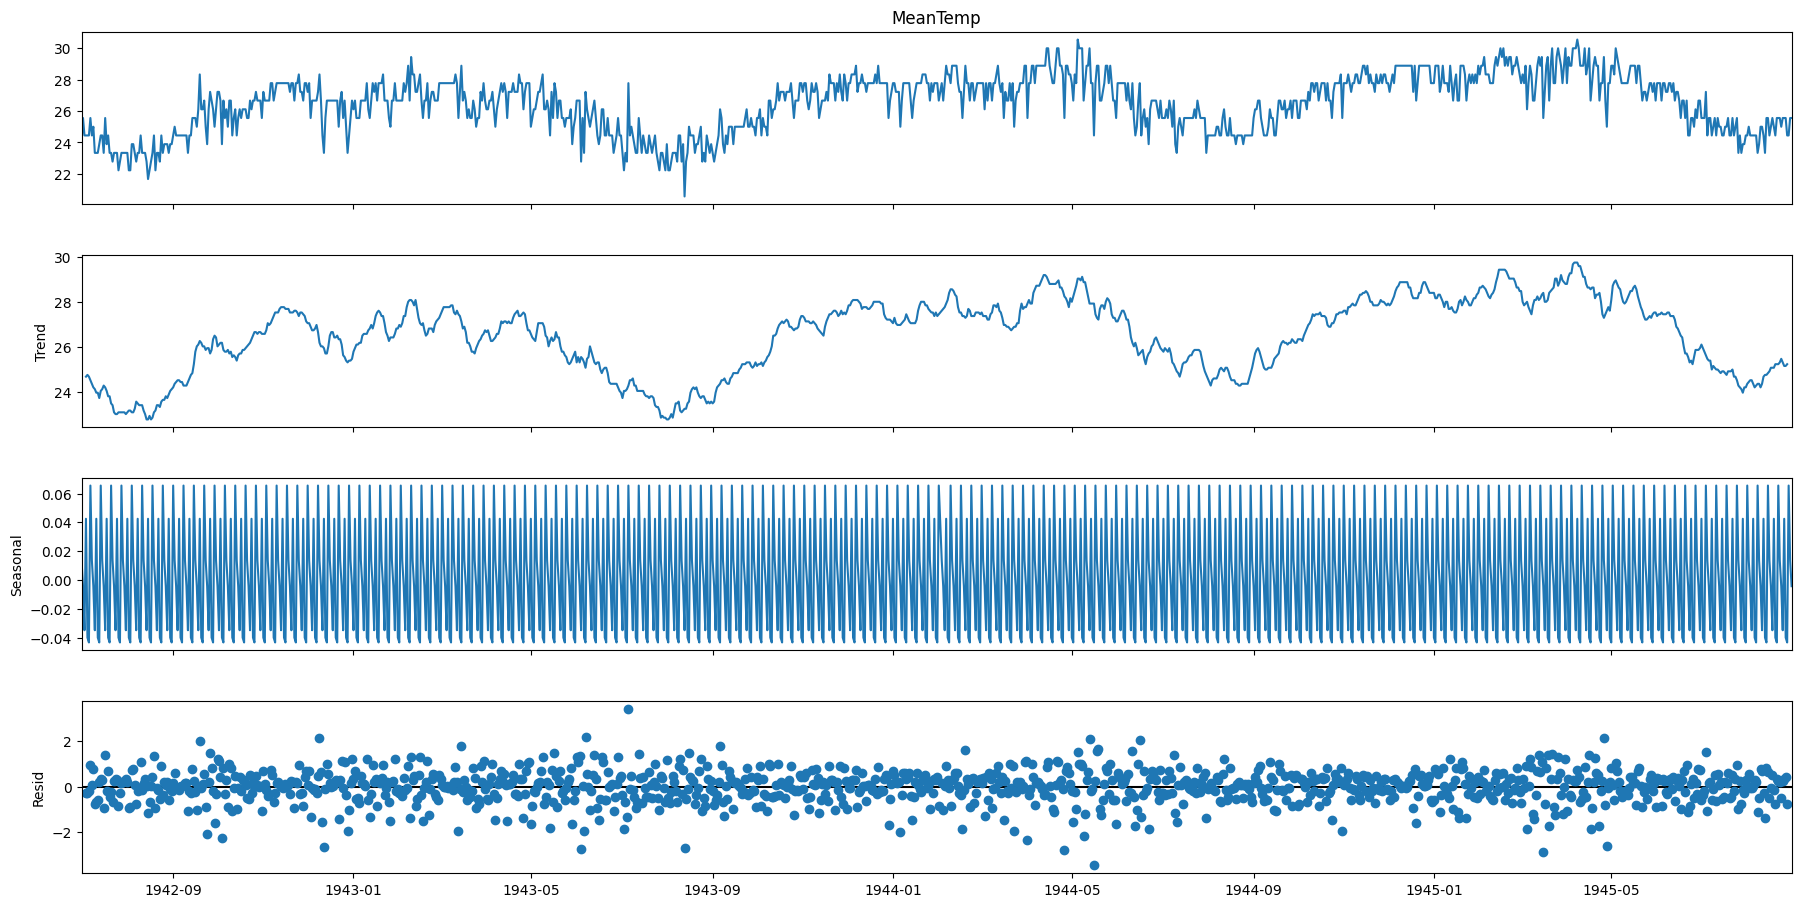

1차 차분 후 ADF Statistic: -14.1837, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


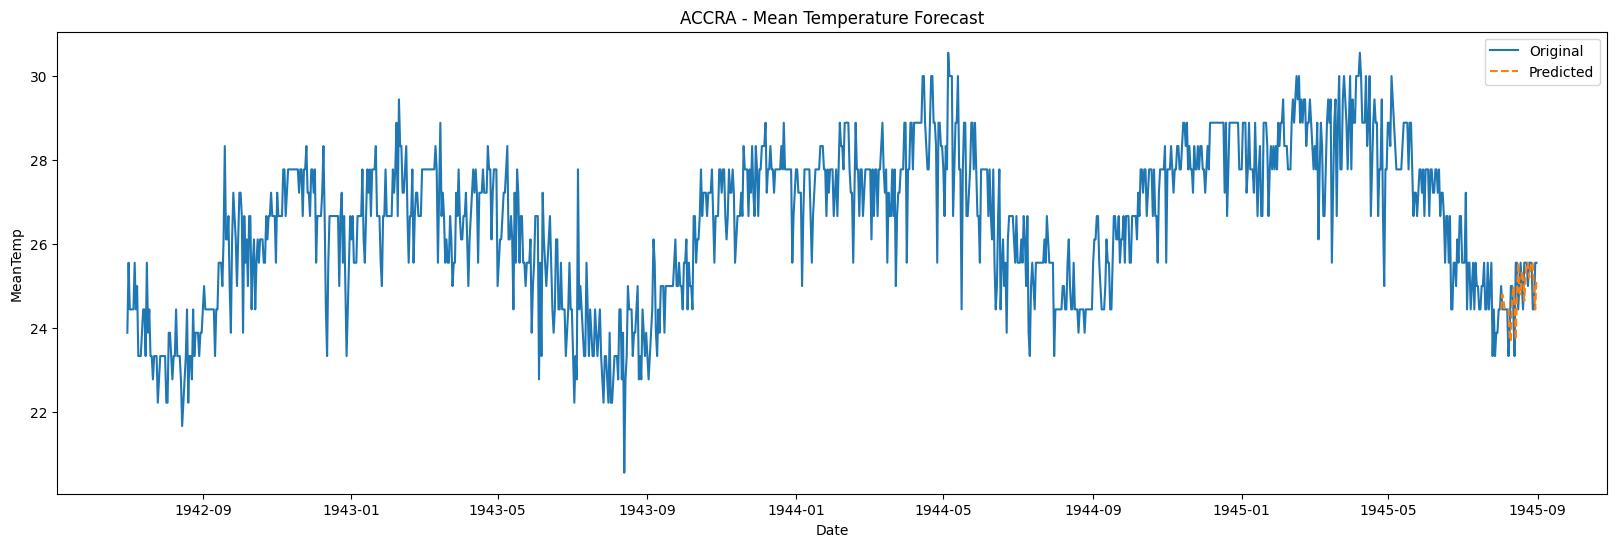

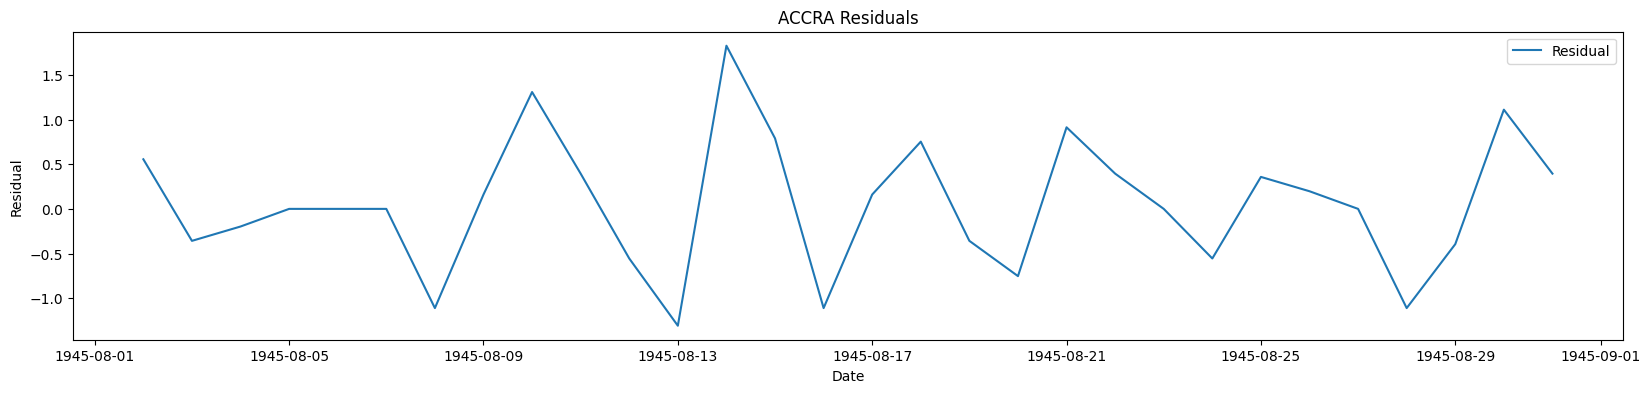

Residual ADF Statistic: -5.3769, p-value: 0.0000
       R2   Corr   RMSE   MAPE
0 -28.129  0.239  0.738  2.303

===== 분석: AGRA =====


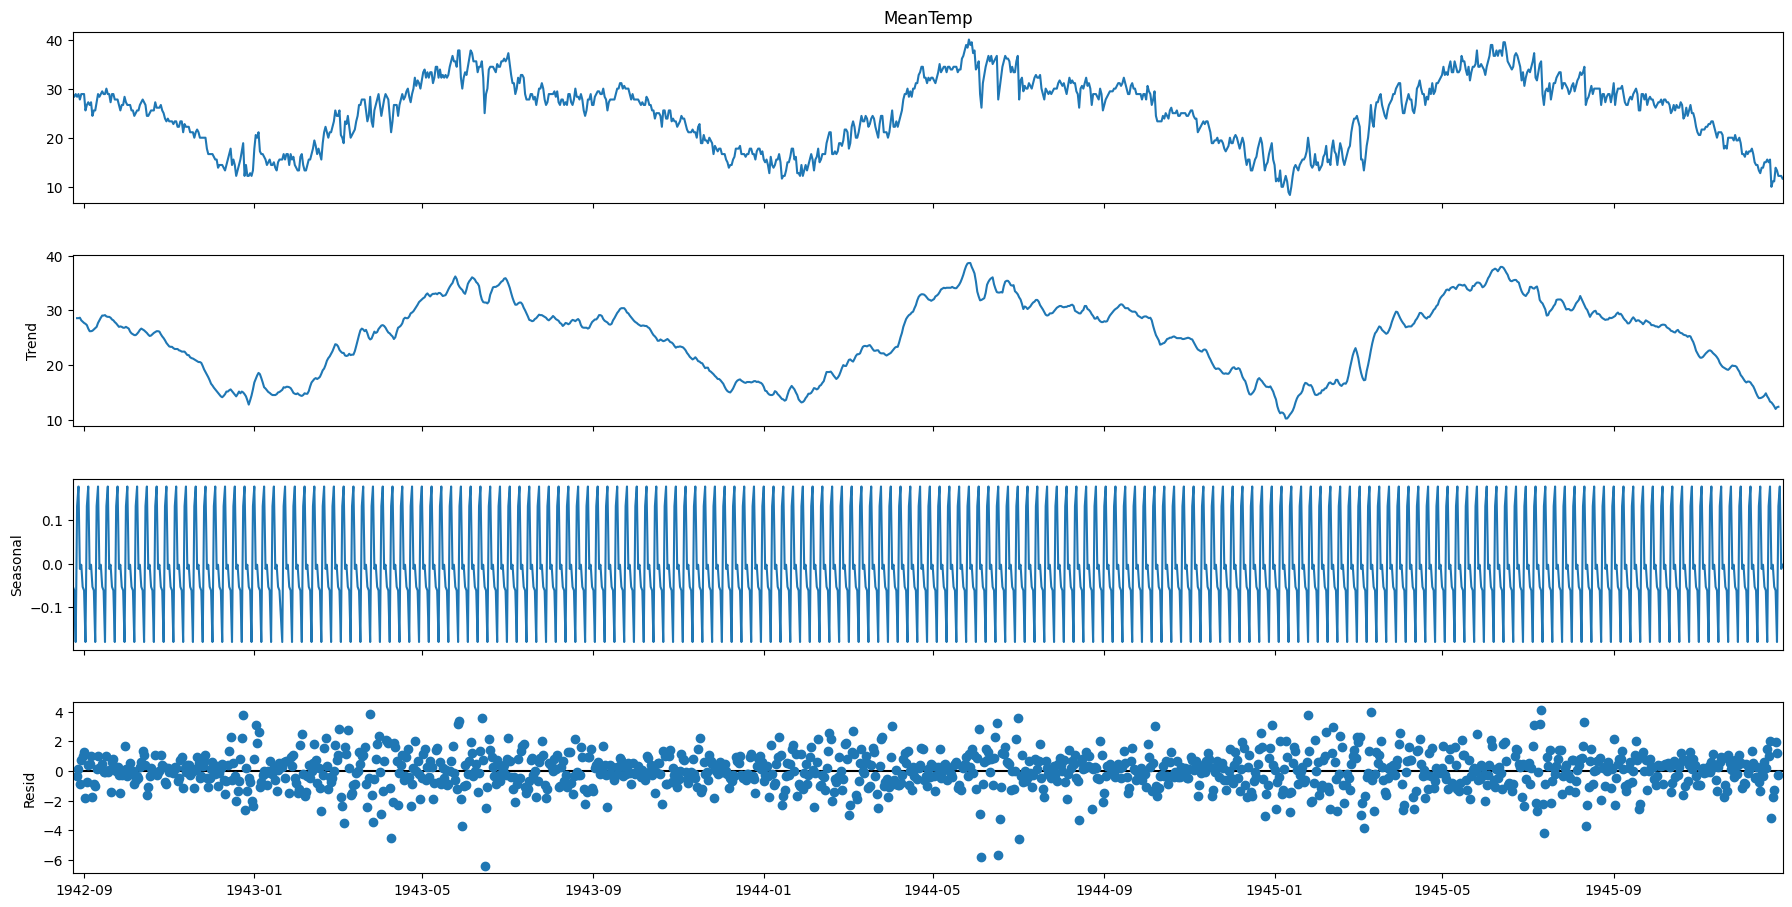

1차 차분 후 ADF Statistic: -6.2947, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


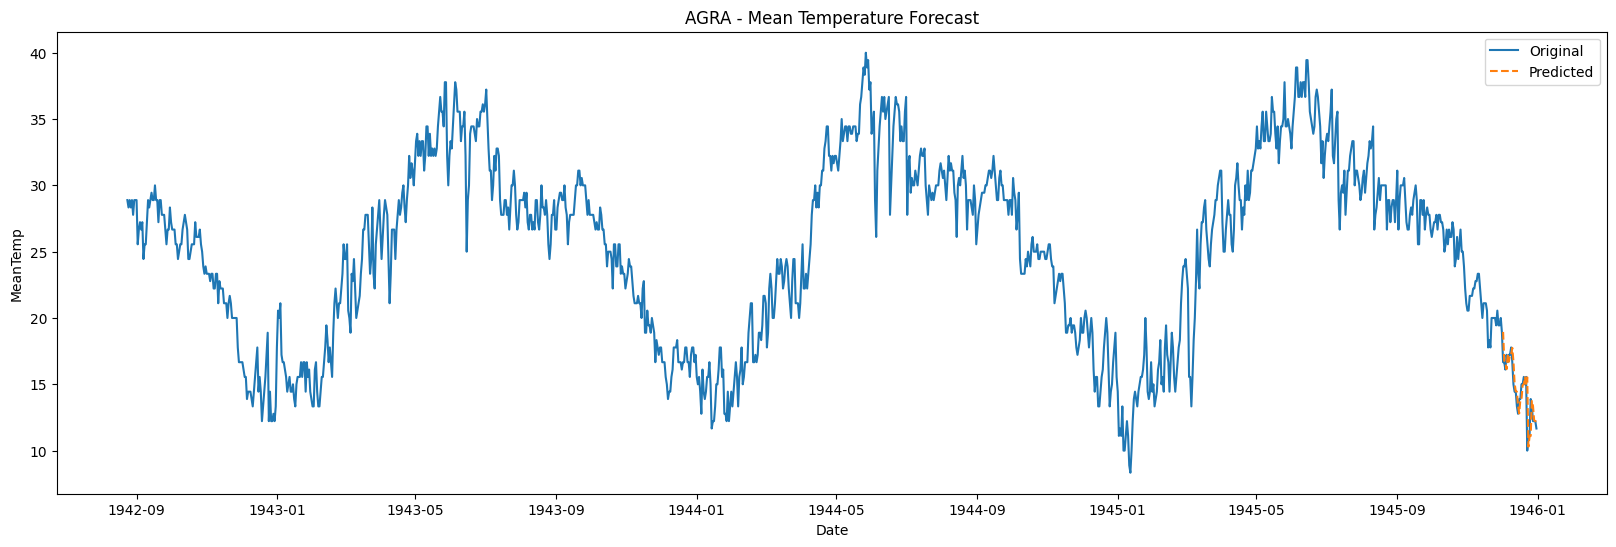

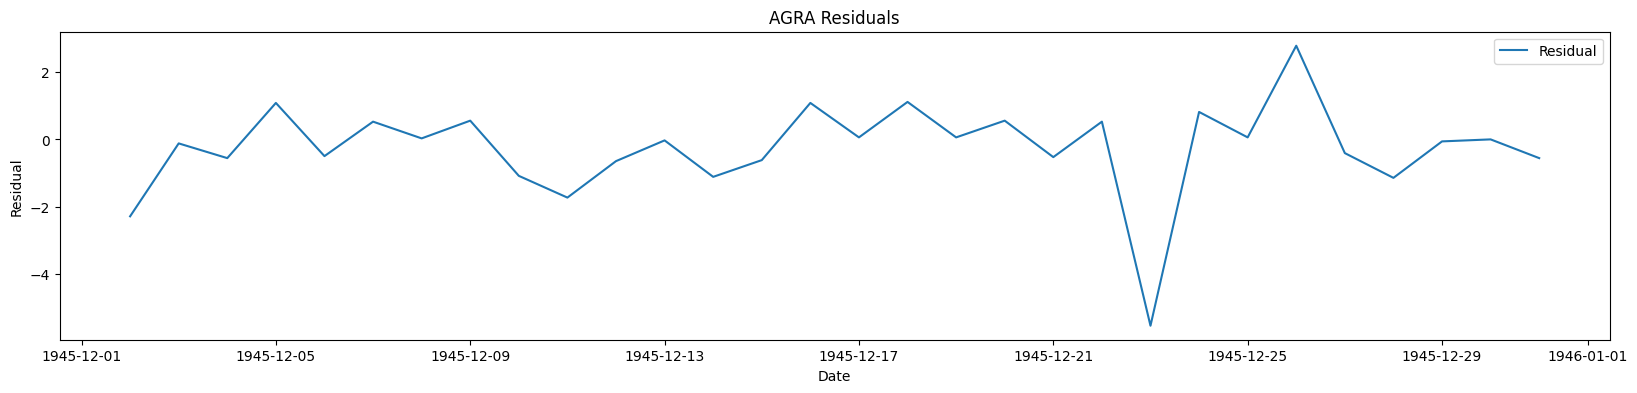

Residual ADF Statistic: -6.2506, p-value: 0.0000
       R2   Corr   RMSE  MAPE
0  56.026  0.794  1.387  6.55

===== 분석: AMBERLY =====


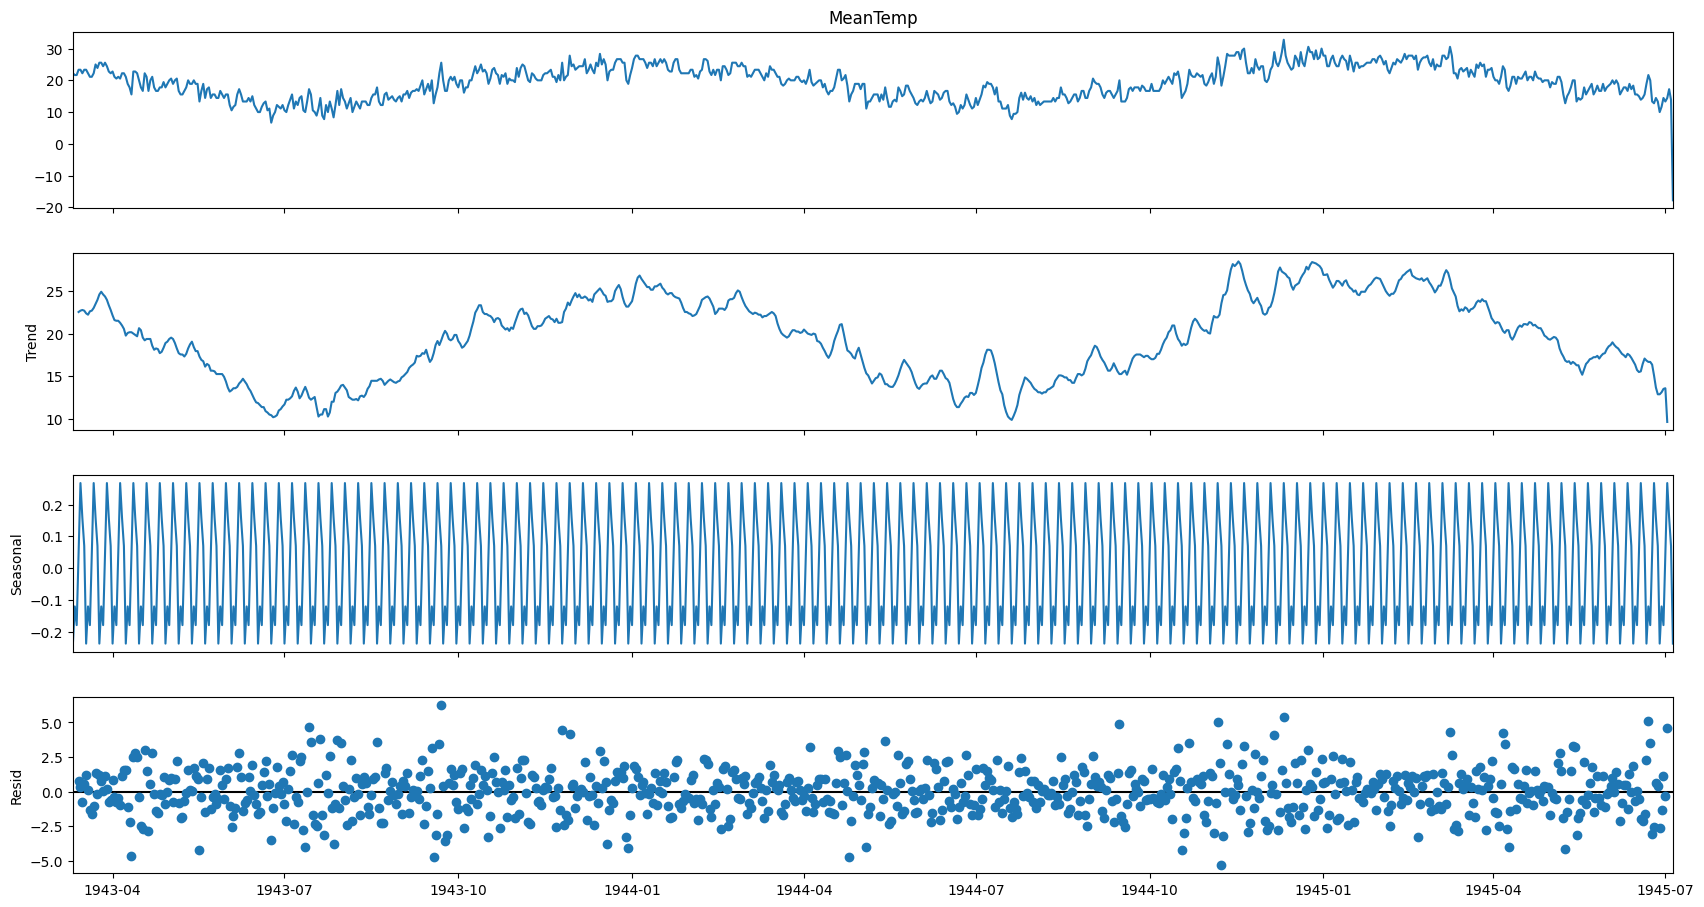

1차 차분 후 ADF Statistic: -13.1012, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


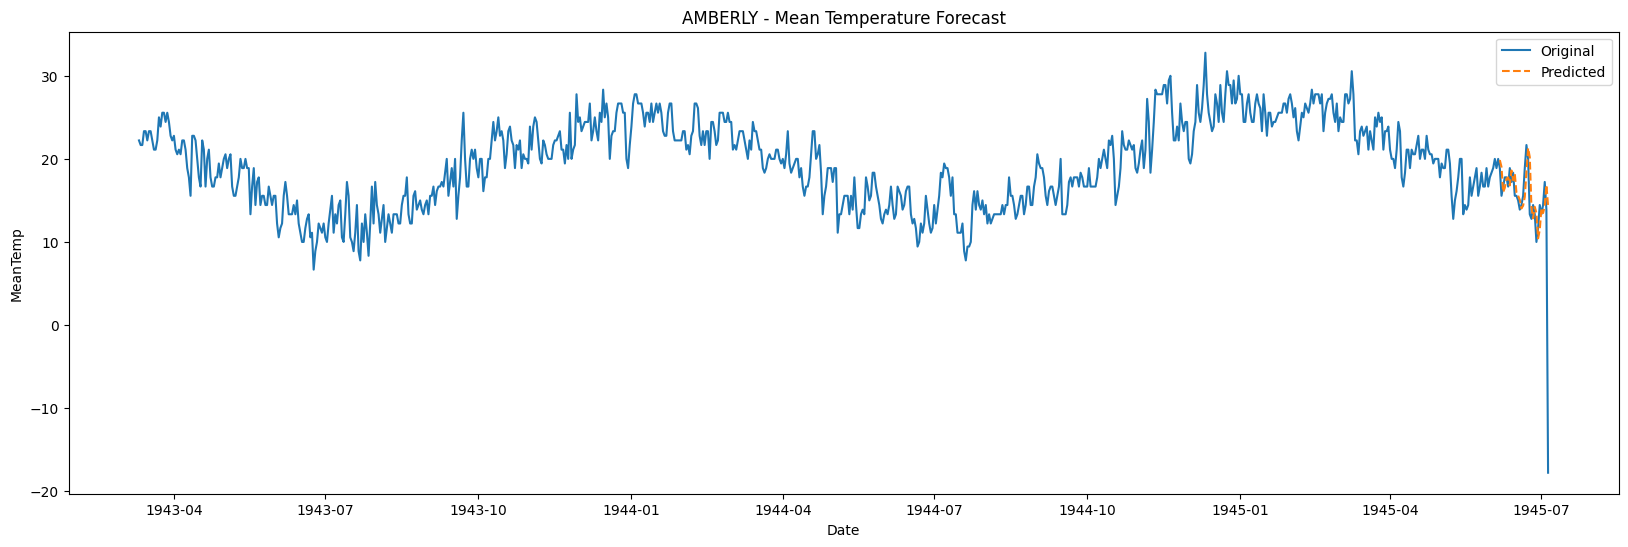

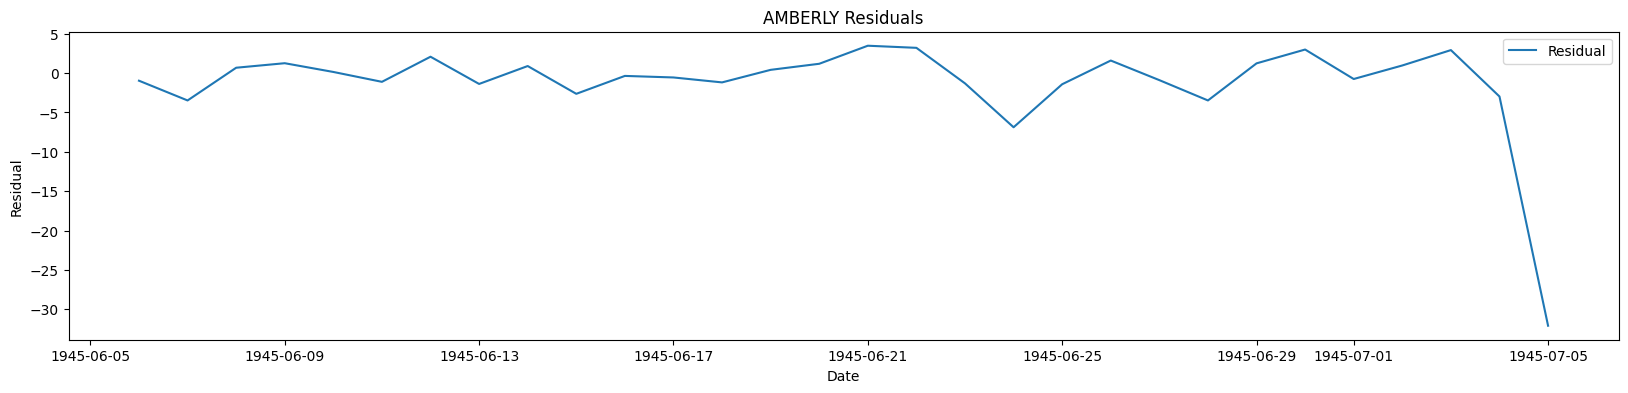

Residual ADF Statistic: -2.2786, p-value: 0.1790
     R2   Corr   RMSE    MAPE
0  7.77  0.344  6.277  17.649

===== 분석: AMURI/FIELD AAF =====


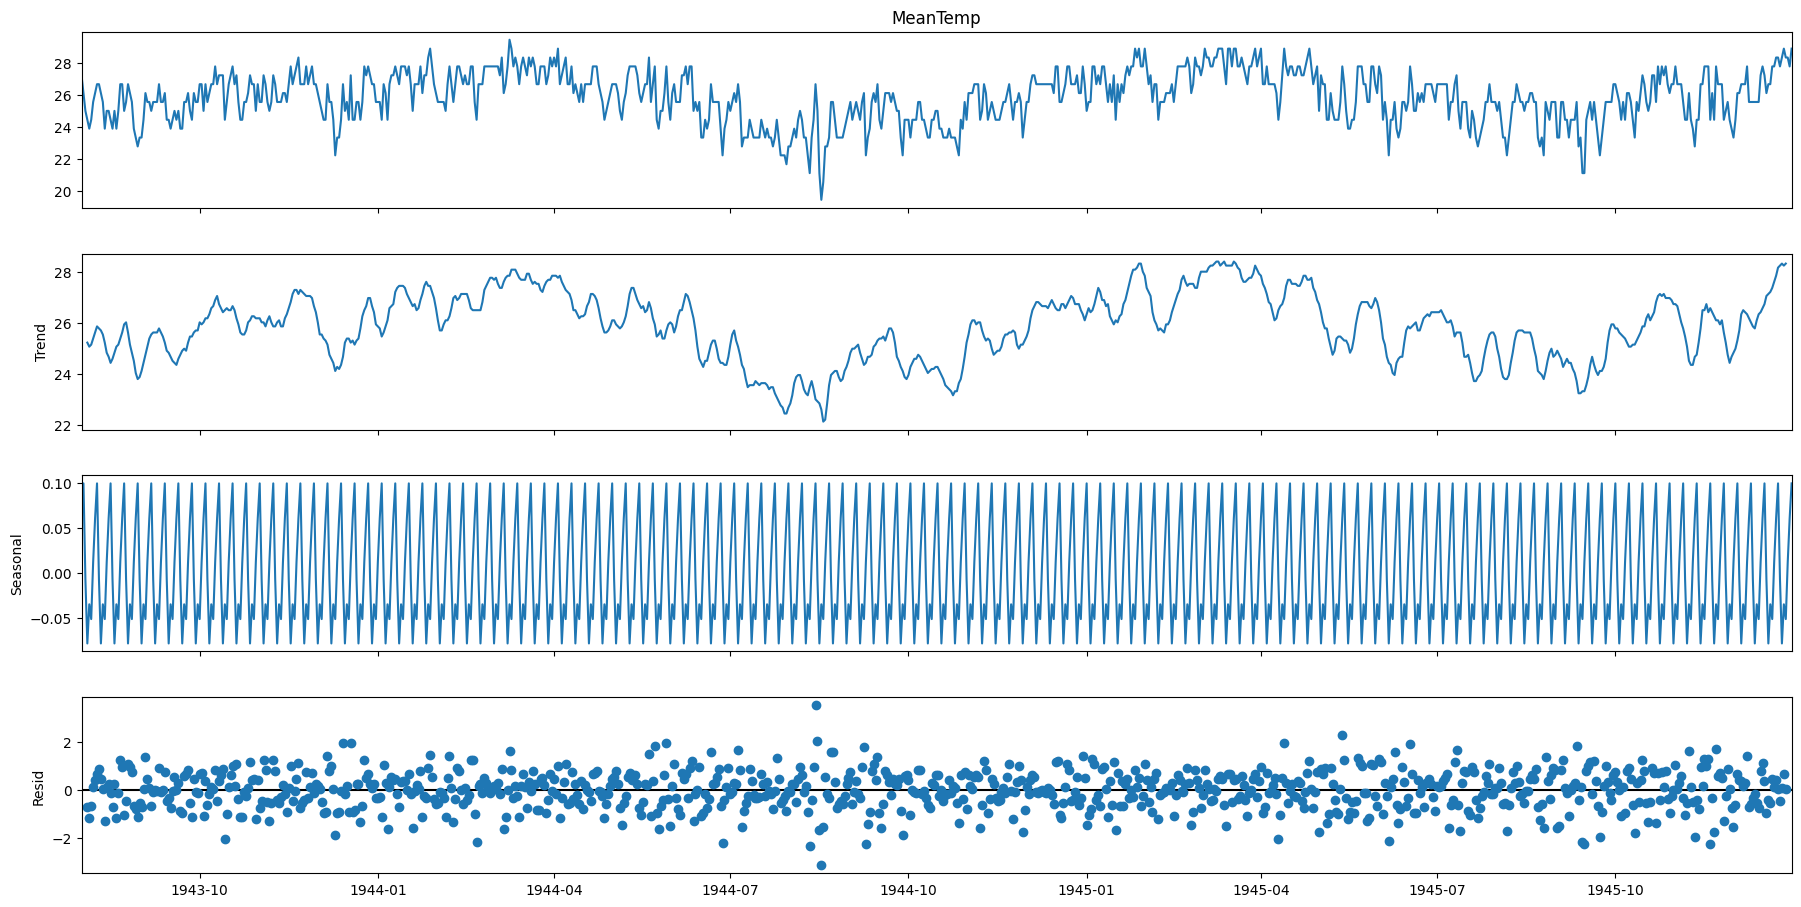

1차 차분 후 ADF Statistic: -11.0736, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


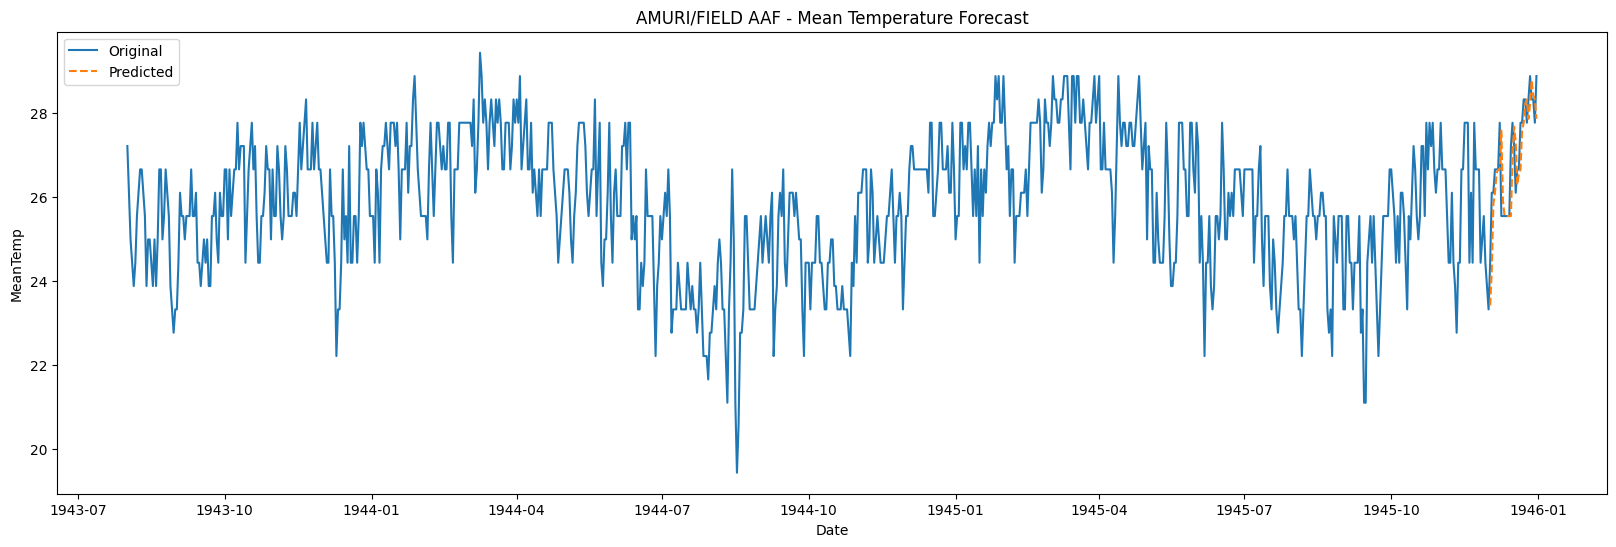

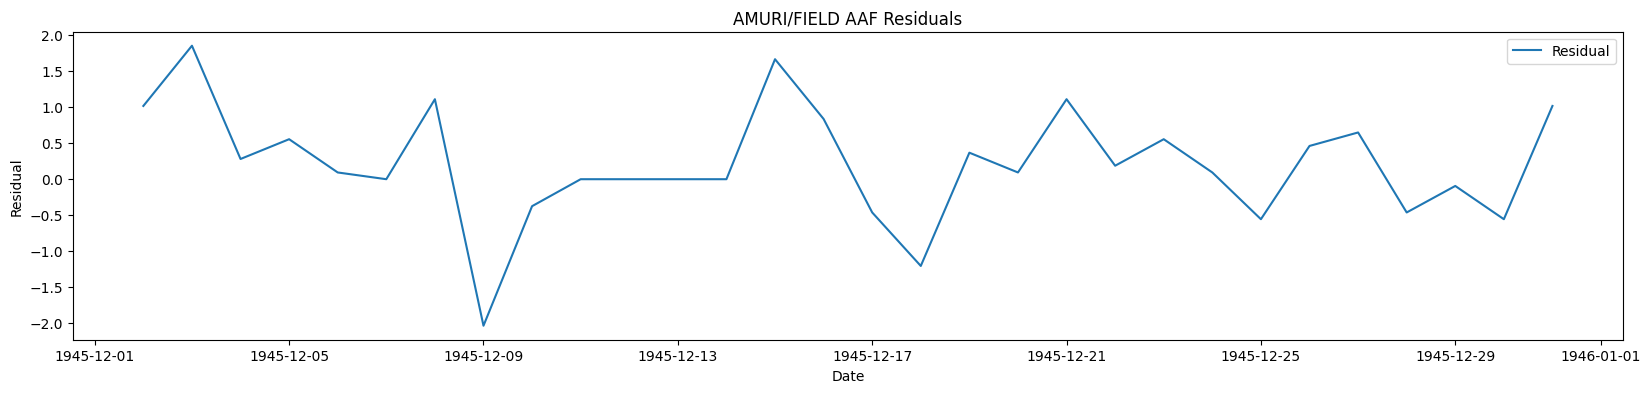

Residual ADF Statistic: -4.9034, p-value: 0.0000
       R2   Corr   RMSE  MAPE
0  52.628  0.799  0.812  2.19

===== 분석: ATAR =====


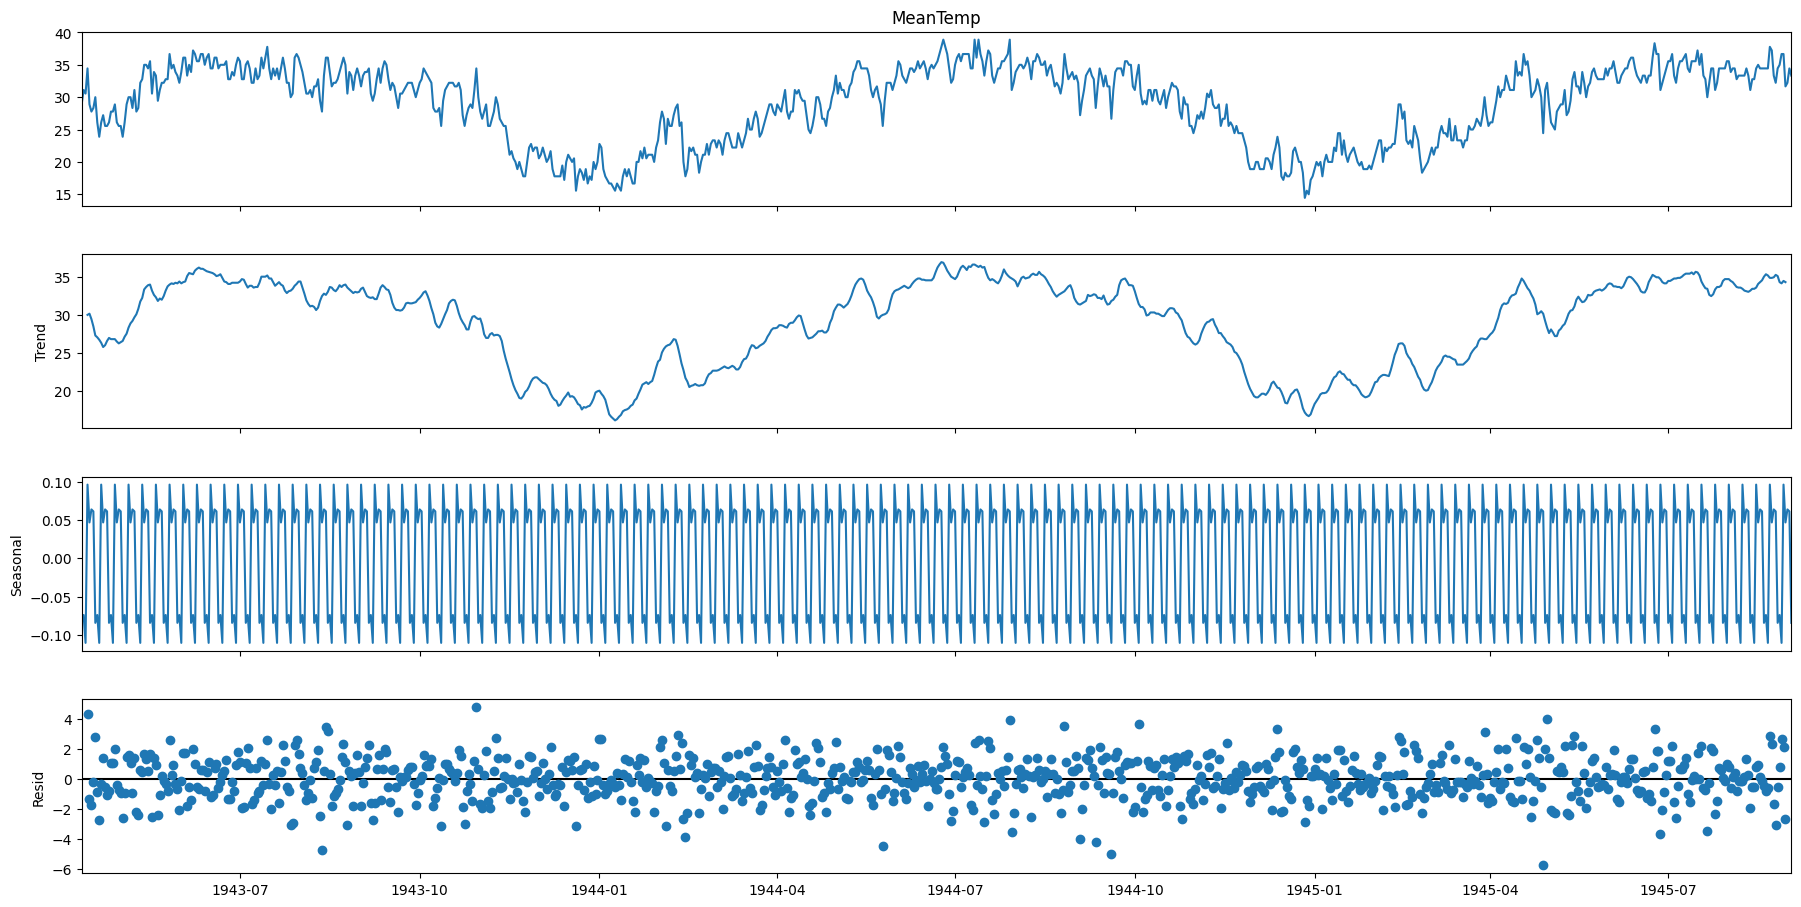

1차 차분 후 ADF Statistic: -11.5465, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


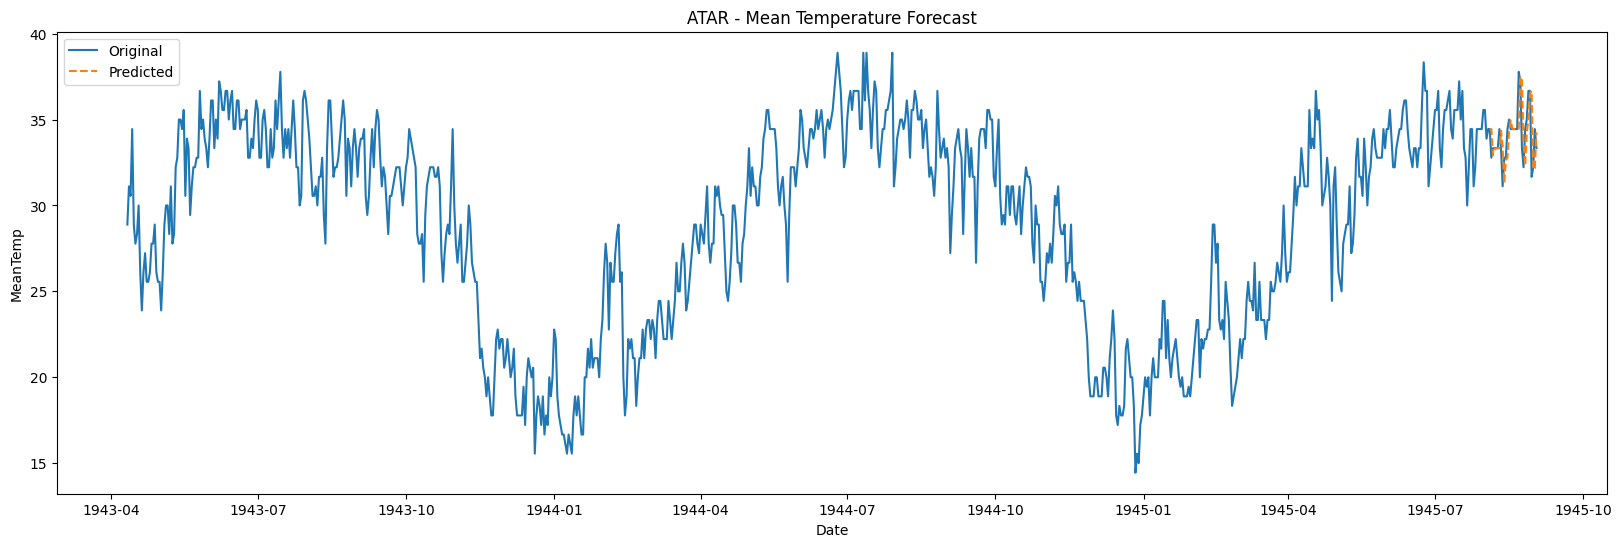

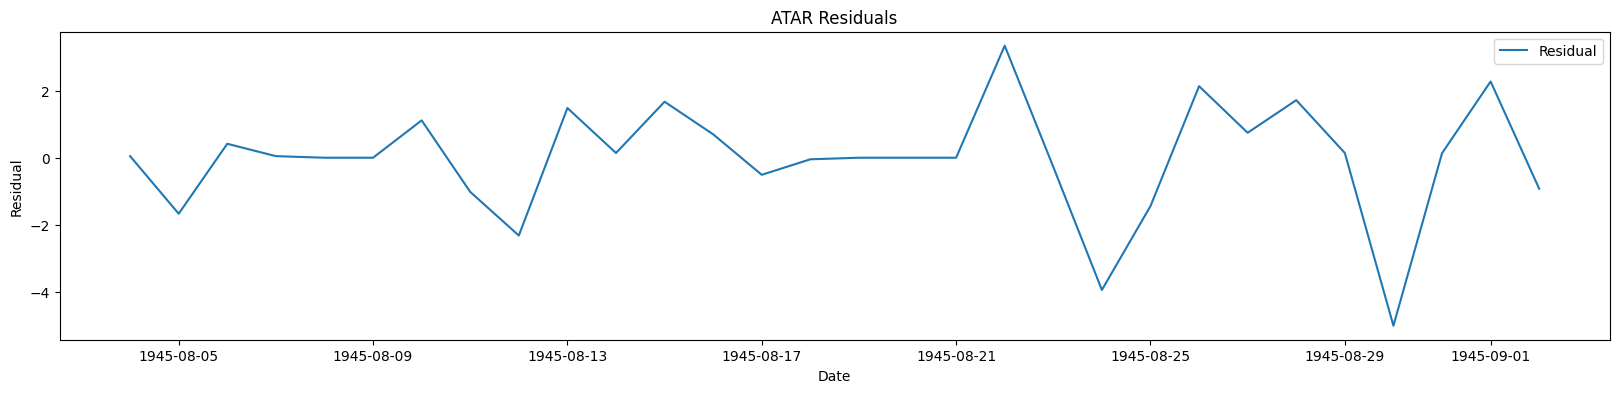

Residual ADF Statistic: -1.5439, p-value: 0.5117
       R2   Corr   RMSE   MAPE
0 -19.389  0.373  1.675  3.282

===== 분석: BALBOA/ALBROOK =====


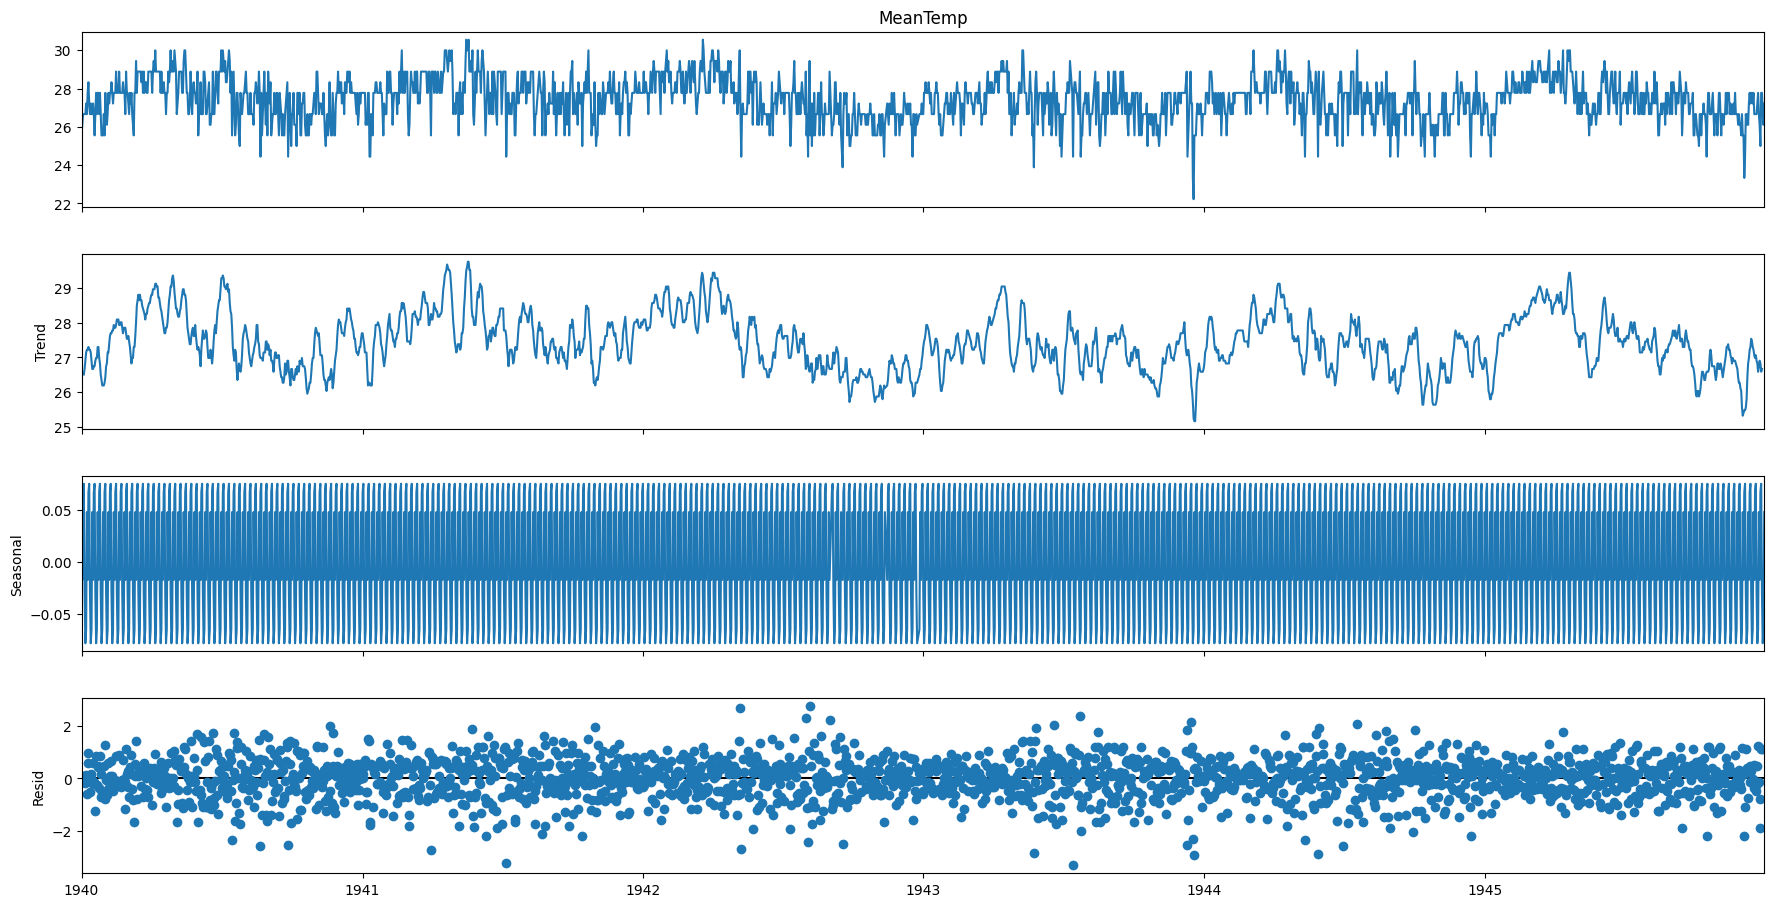

1차 차분 후 ADF Statistic: -14.0578, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


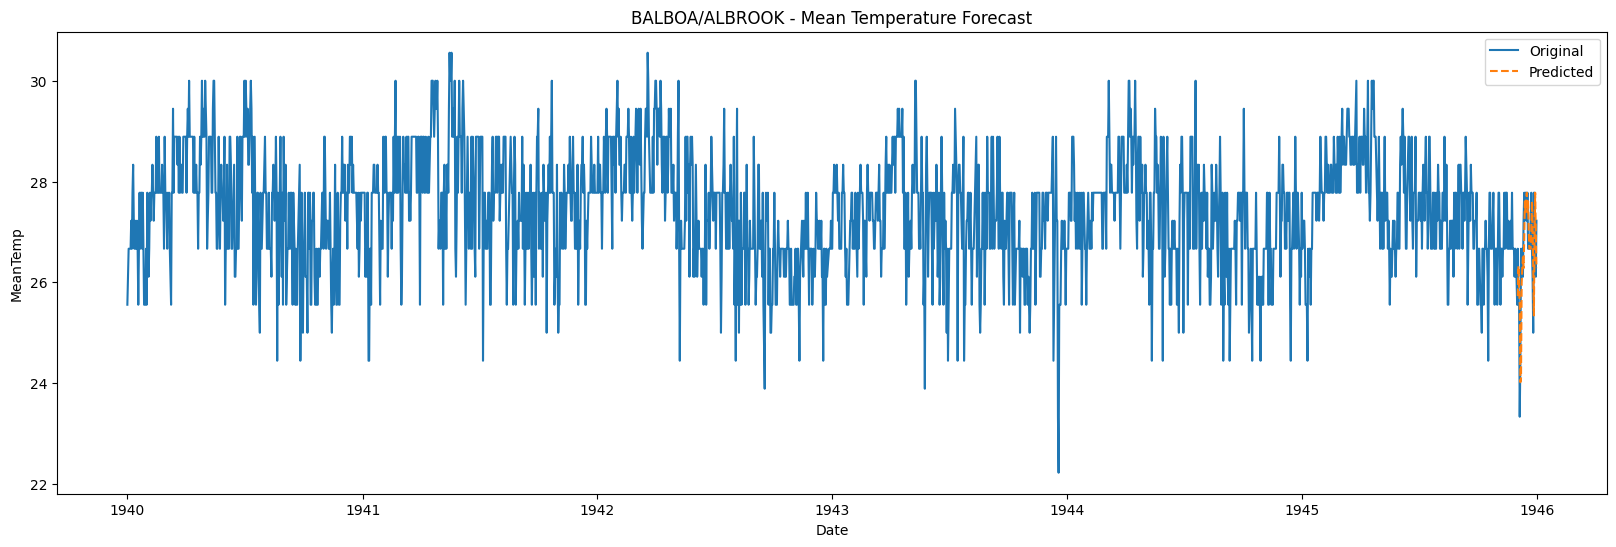

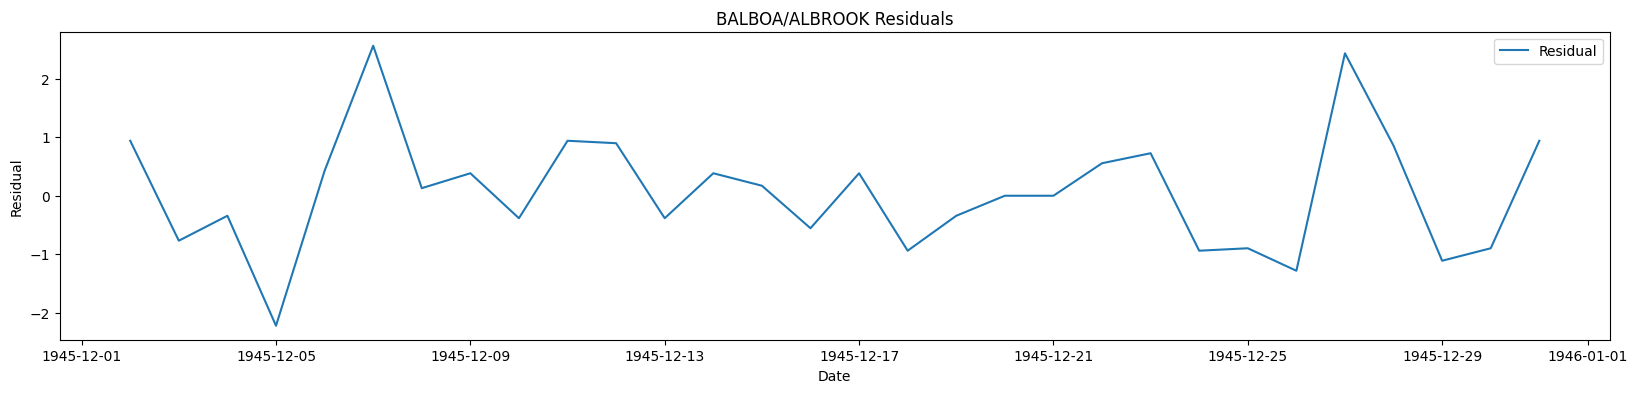

Residual ADF Statistic: -5.1989, p-value: 0.0000
     R2   Corr   RMSE   MAPE
0  5.64  0.485  1.014  3.005

===== 분석: BAMRAULI =====


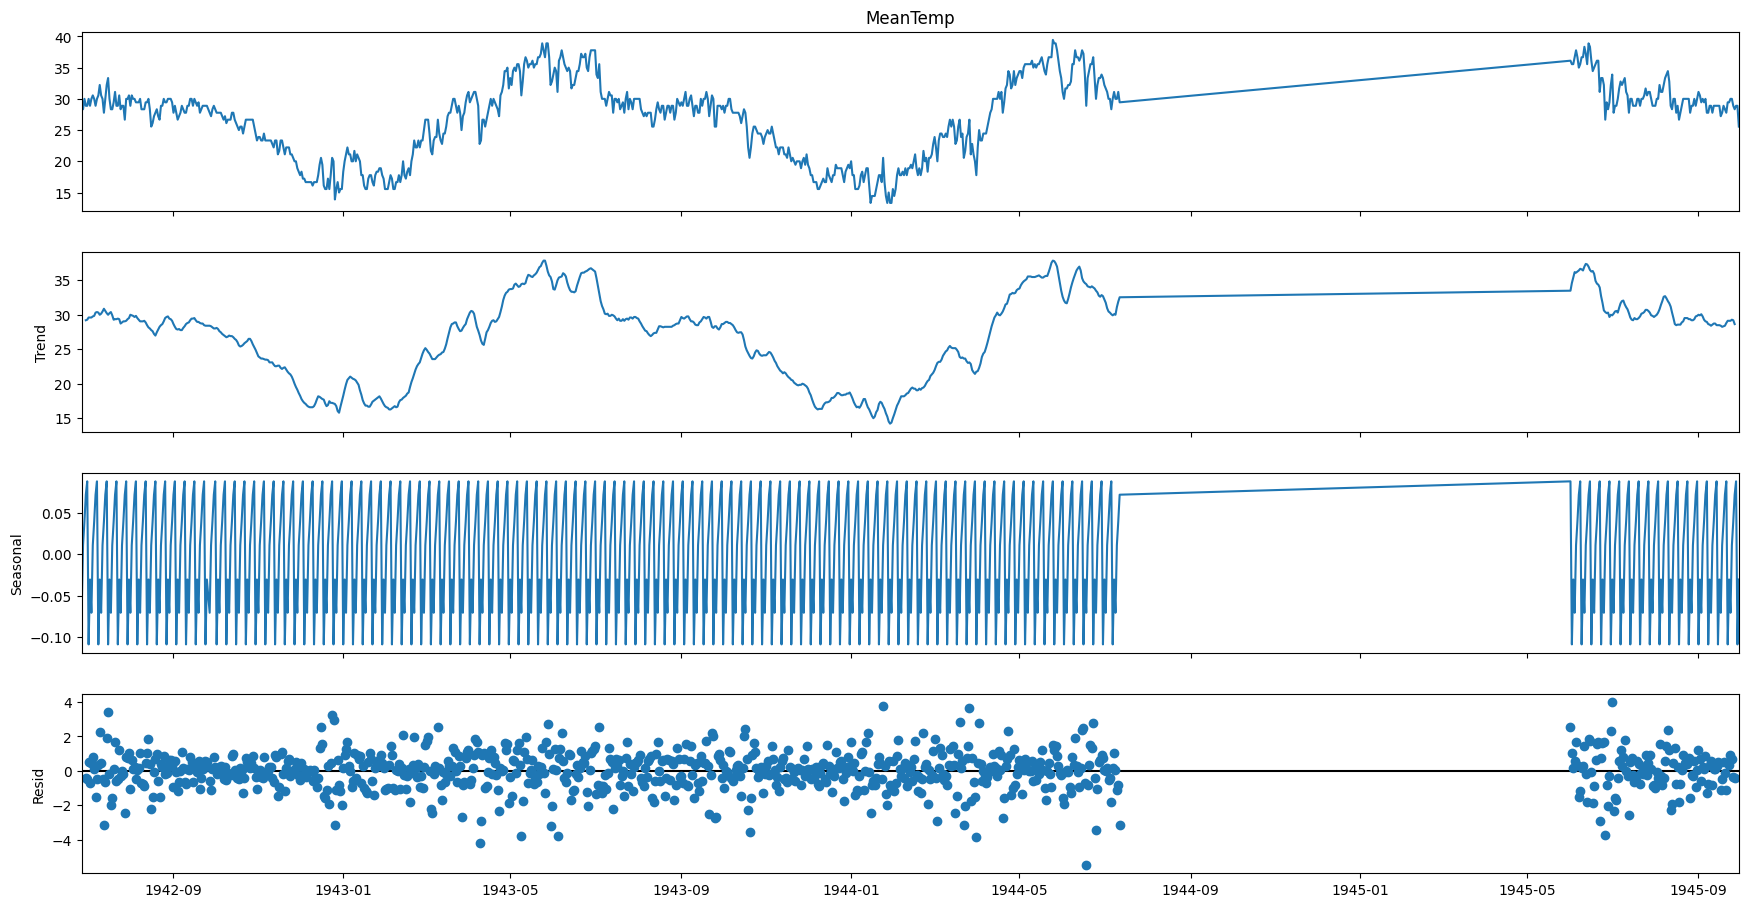

1차 차분 후 ADF Statistic: -13.1138, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


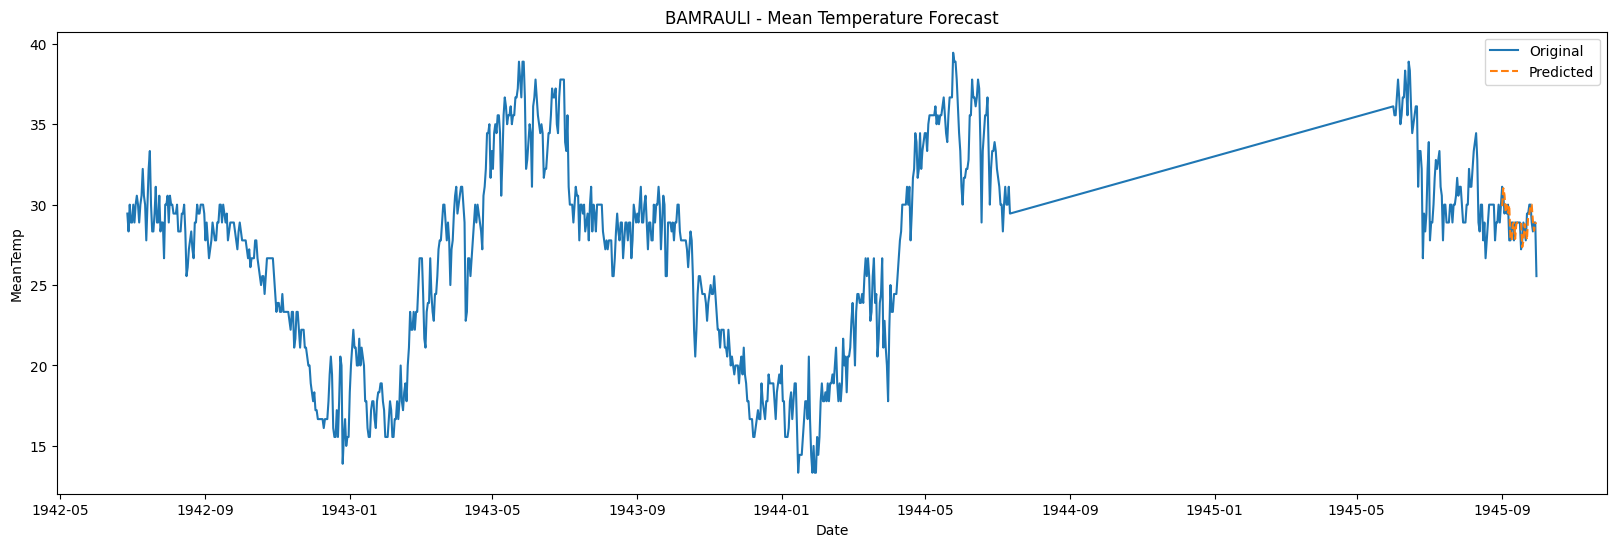

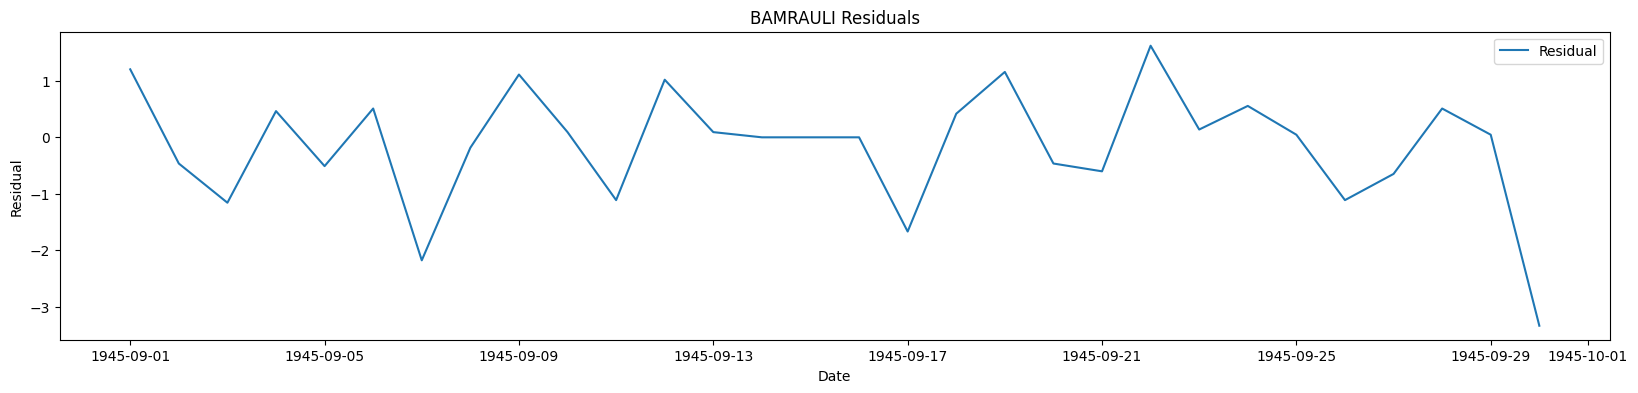

Residual ADF Statistic: -2.8854, p-value: 0.0471
      R2   Corr   RMSE   MAPE
0  4.767  0.445  1.047  2.643

===== 분석: BANGALORE =====


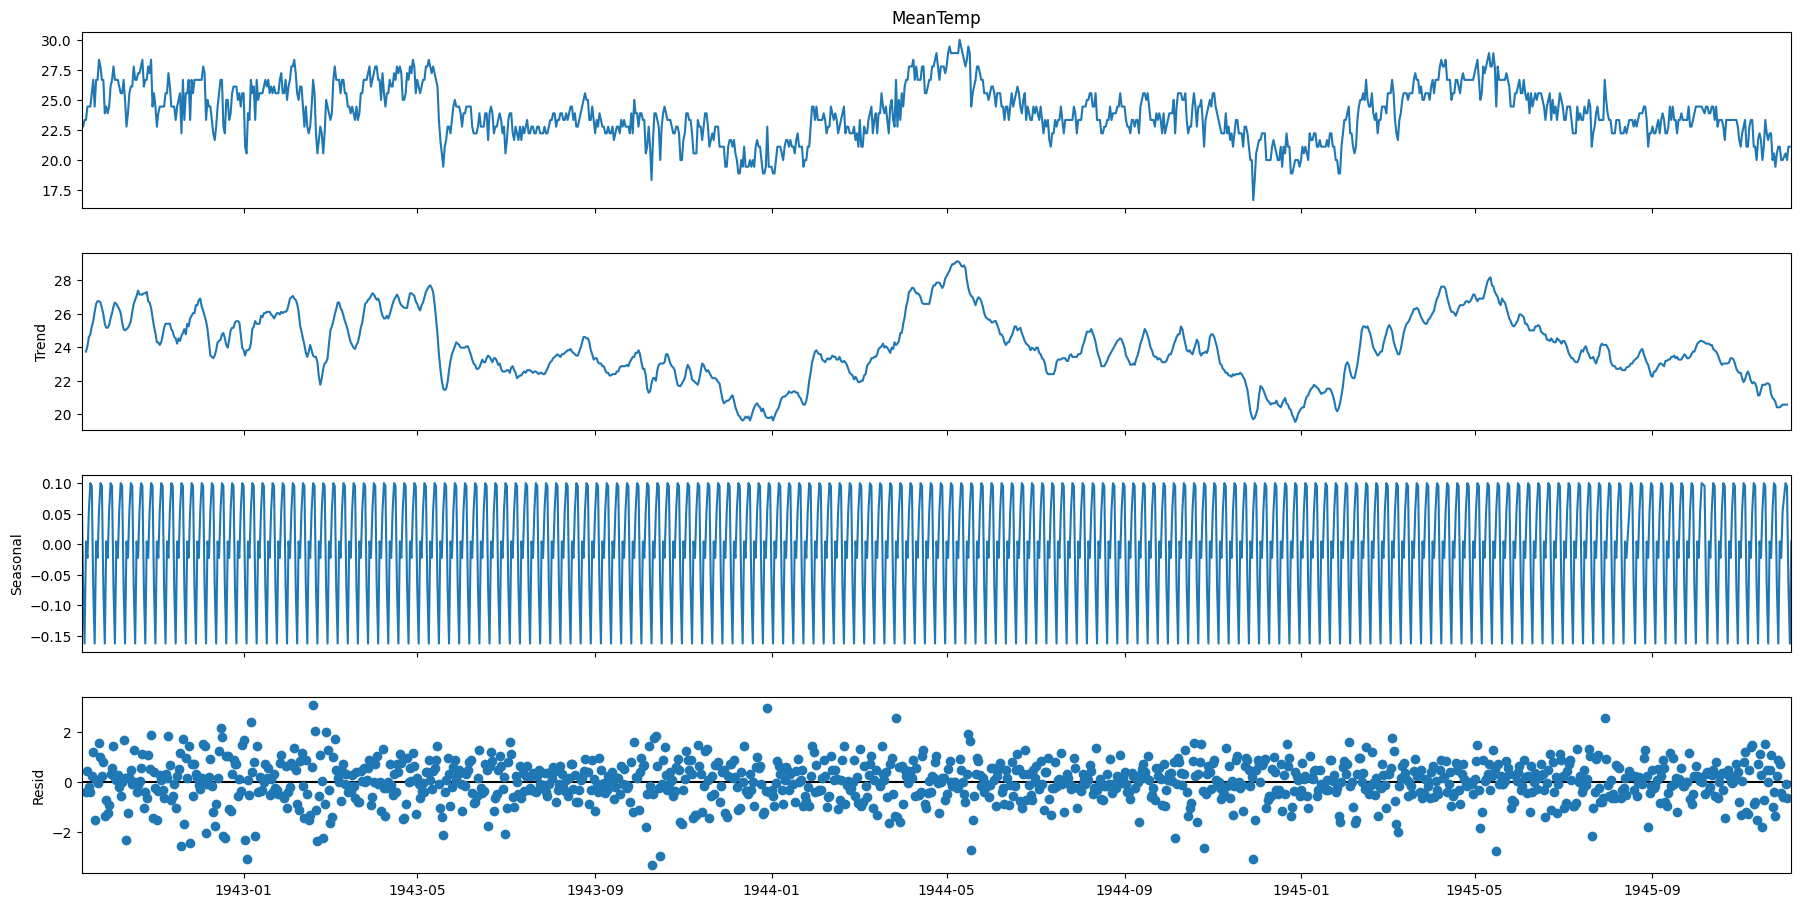

1차 차분 후 ADF Statistic: -14.4613, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


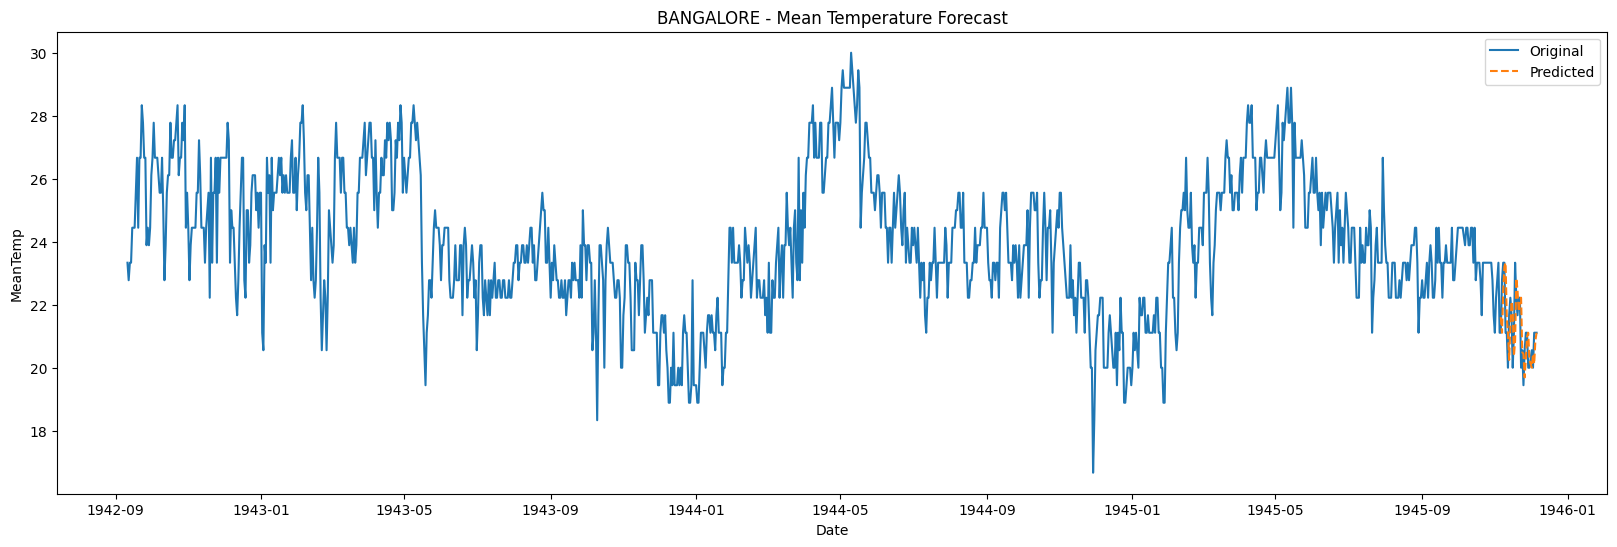

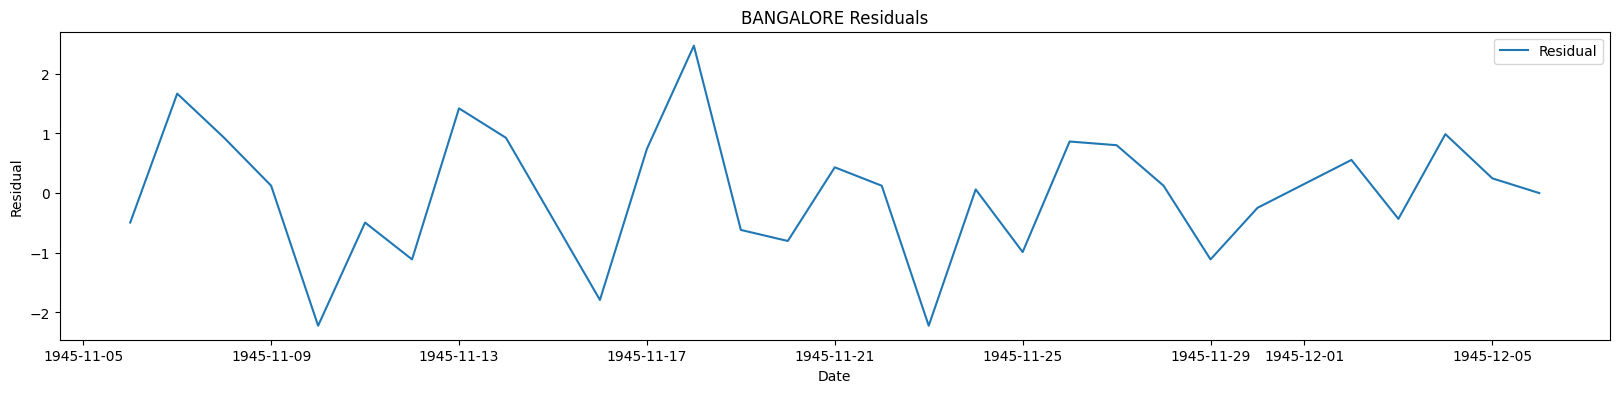

Residual ADF Statistic: -5.1982, p-value: 0.0000
      R2   Corr   RMSE   MAPE
0 -2.033  0.443  1.074  3.996

===== 분석: BERMUDA =====


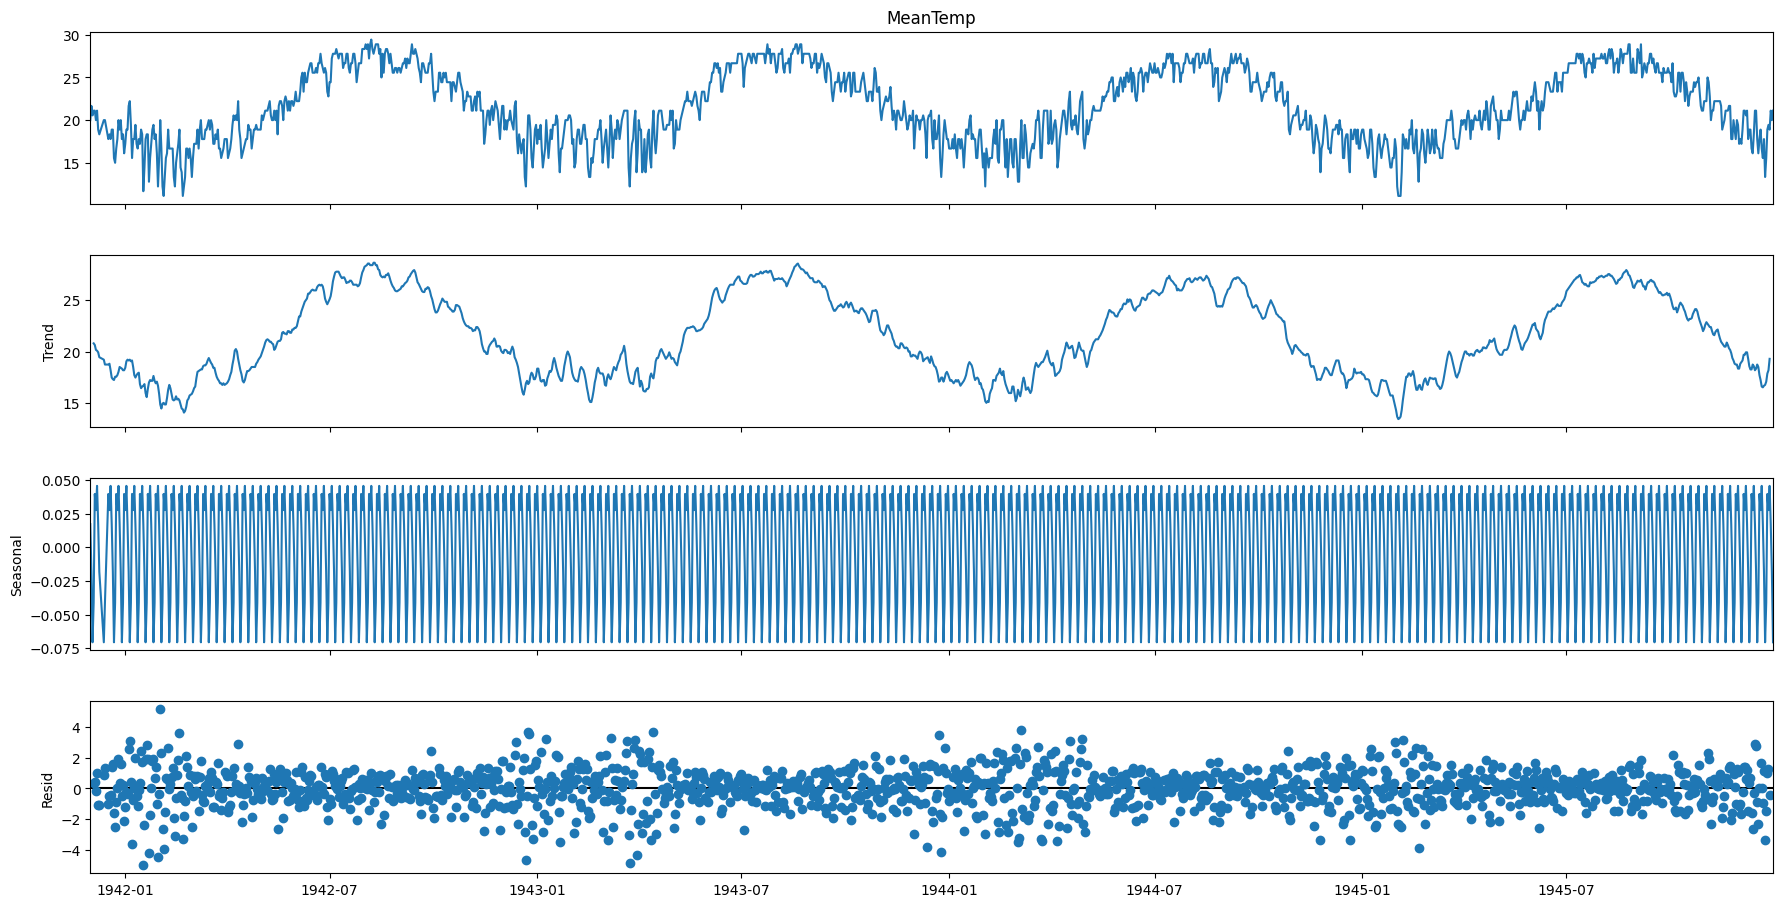

1차 차분 후 ADF Statistic: -17.0301, p-value: 0.0000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


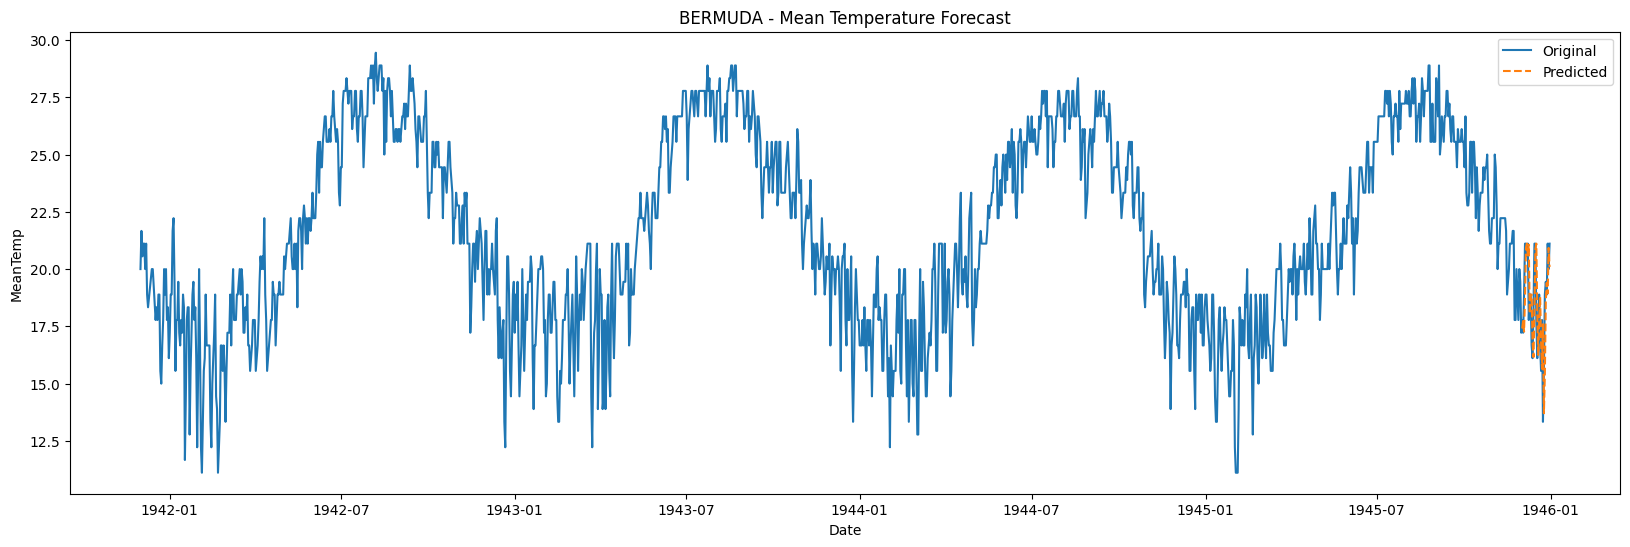

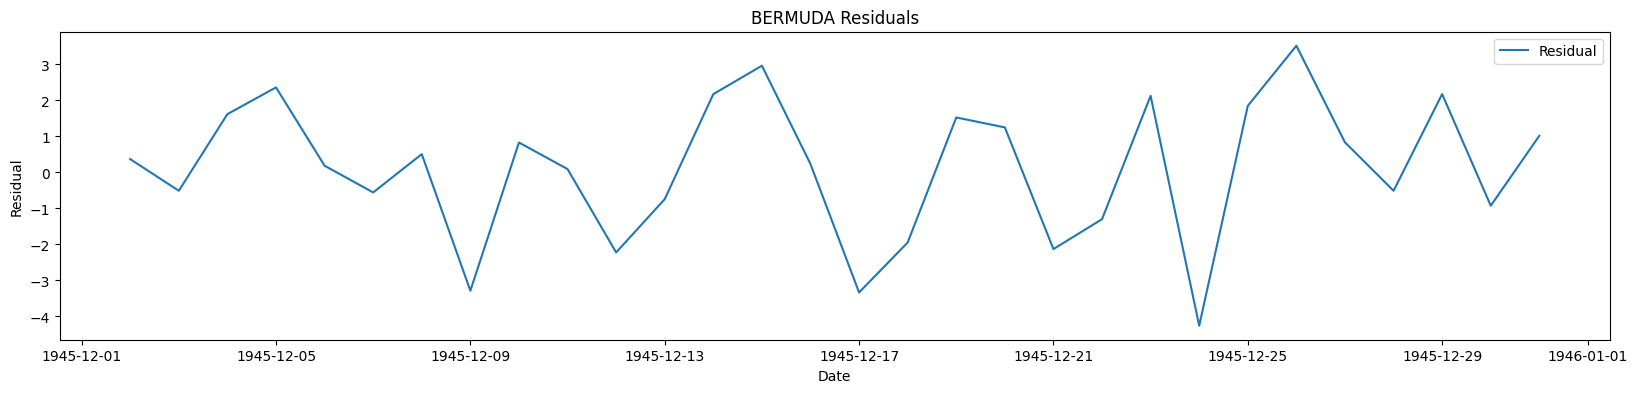

Residual ADF Statistic: -5.1525, p-value: 0.0000
      R2   Corr   RMSE   MAPE
0  9.472  0.522  1.922  8.915


In [39]:
# 성능 평가 함수
def scoring(y_true, y_pred):
    r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
    corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
    mape = round(metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3)
    rmse = round(np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3)

    return pd.DataFrame({
        "R2": r2,
        "Corr": corr,
        "RMSE": rmse,
        "MAPE": mape
    }, index=[0])

# 데이터 충분한 도시 리스트
cities = ['ACCRA', 'AGRA', 'AMBERLY', 'AMURI/FIELD AAF', 'ATAR', 'BALBOA/ALBROOK', 'BAMRAULI', 'BANGALORE', 'BERMUDA']

# ARIMA 기본 하이퍼파라미터
p, d, q = 1, 1, 0

for city in cities:
    print(f"\n===== 분석: {city} =====")

    # 도시별 데이터 필터링
    loc_sta = loc_df[loc_df["NAME"] == city].WBAN
    city_df = weather_df[weather_df.STA.isin(loc_sta)].copy()

    # 날짜 변환 및 정렬
    city_df["Date"] = pd.to_datetime(city_df["Date"])
    city_df = city_df.sort_values("Date")

    # 결측치 처리
    city_df["MeanTemp"] = city_df["MeanTemp"].ffill()
    city_df["Precip"] = city_df["Precip"].fillna(0)

    ts = city_df.set_index("Date")

    # 시계열 분해
    try:
        result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)
        fig = result.plot()
        fig.set_size_inches(20, 10)
        plt.show()
    except Exception as e:
        print(f"Seasonal decomposition 실패: {e}")

    # 차분 및 정상성 검정
    ts_diff = ts["MeanTemp"].diff().dropna()
    result_adf = adfuller(ts_diff)
    print(f"1차 차분 후 ADF Statistic: {result_adf[0]:.4f}, p-value: {result_adf[1]:.4f}")

    # ARIMA 학습
    try:
        model = ARIMA(ts["MeanTemp"], order=(p,d,q))
        model_fit = model.fit()
    except Exception as e:
        print(f"ARIMA 학습 실패: {e}")
        continue

    # 예측: 마지막 30일
    start_index = ts.index[-30]
    end_index = ts.index[-1]
    forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

    # 시각화
    plt.figure(figsize=(20,6))
    plt.plot(ts.index, ts["MeanTemp"], label="Original")
    plt.plot(forecast.index, forecast, label="Predicted", linestyle="--")
    plt.title(f"{city} - Mean Temperature Forecast")
    plt.xlabel("Date")
    plt.ylabel("MeanTemp")
    plt.legend()
    plt.show()

    # 잔차 분석
    resi = ts.loc[start_index:end_index, "MeanTemp"] - forecast
    plt.figure(figsize=(20,4))
    plt.plot(resi.index, resi, label="Residual")
    plt.title(f"{city} Residuals")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.legend()
    plt.show()

    # 잔차 정상성 검정
    resi_adf = adfuller(resi)
    print(f"Residual ADF Statistic: {resi_adf[0]:.4f}, p-value: {resi_adf[1]:.4f}")

    # 성능 평가
    score_df = scoring(np.array(ts.loc[start_index:end_index, "MeanTemp"]), np.array(forecast))
    print(score_df)

ACCRA는 1차 차분 후 정상성을 확보했지만, R²가 -28.129로 낮아 예측력이 제한적이며, 상관계수 0.239, RMSE 0.738로 오차가 존재한다.

AGRA는 정상성을 만족하고 비교적 높은 예측력을 보여 ARIMA 모델이 기온 변화를 잘 설명한다.

AMBERLY는 잔차 정상성을 만족하지 않아 모델 예측력이 낮으며, 계절성 또는 외부 요인 고려가 필요하다.

AMURI/FIELD AAF는 정상성을 확보하고 상관계수 0.799, RMSE 0.812로 안정적인 예측이 가능하다.

ATAR는 잔차 정상성이 없고 예측력이 낮아 ARIMA 단독 적용에는 한계가 있다.

BALBOA/ALBROOK, BAMRAULI, BANGALORE, BERMUDA는 정상성을 확보했으나 예측력 향상을 위해 계절성, 외부 변수, 모델 튜닝이 필요하다.

종합하면 대부분의 도시에서 시계열 정상성을 확보했으나, 도시별로 ARIMA 모델의 예측력은 차이가 크며, 일부 도시는 단독 적용보다는 추가적인 개선이 필요하다.